# LSTM

#### Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, Dict
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error


### Load Data

In [2]:
df = pd.read_csv("swift_creek_usgs_data_2020_2024.csv")
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime')
df

,Discharge (cfs),Water Temperature (C),pH (std units),Dissolved Oxygen (mg/L),Specific Conductance (uS/cm),Turbidity (NTU),Total Organic Carbon (mg/L),Nitrate + Nitrite (mg/L),Total Phosphorus (mg/L),Precipitation 1hr (in)
DateTime,,,,,,,,,,
2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2020-01-01 01:00:00,96.0,12.2,7.3,9.8,438.0,39.0,11.0,3.03,0.911,0.0
2020-01-01 02:00:00,93.0,12.2,7.3,9.8,439.0,46.0,12.0,3.05,0.938,0.0
2020-01-01 03:00:00,93.0,12.2,7.3,9.8,440.0,39.0,11.0,3.06,0.916,0.0
2020-01-01 04:00:00,90.0,12.2,7.3,9.8,440.0,40.0,11.0,3.07,0.918,0.0
...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,260.0,18.0,7.4,8.6,234.0,99.0,14.0,1.05,0.483,0.0
2024-12-31 20:00:00,255.0,17.6,7.4,8.6,238.0,95.0,14.0,1.08,0.490,0.0
2024-12-31 21:00:00,248.0,17.2,7.4,8.6,240.0,93.0,14.0,1.09,0.493,0.0


In [3]:
df.isna().sum()

Discharge (cfs)                 5308
Water Temperature (C)           5308
pH (std units)                  5308
Dissolved Oxygen (mg/L)         5308
Specific Conductance (uS/cm)    5308
Turbidity (NTU)                 5308
Total Organic Carbon (mg/L)     5308
Nitrate + Nitrite (mg/L)        5308
Total Phosphorus (mg/L)         5308
Precipitation 1hr (in)             0
dtype: int64

In [128]:
url = (
        "https://nrtwq.usgs.gov/explore/datatable?"
        f"site_no=08068500&pcode=00060&period=2024_all_all&timestep=uv&format=rdb&is_verbose=y"
    )
url

'https://nrtwq.usgs.gov/explore/datatable?site_no=08068500&pcode=00060&period=2024_all_all&timestep=uv&format=rdb&is_verbose=y'

### Create Dataset Class

In [4]:
def temporal_splits(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    df = df.sort_index()
    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DatetimeIndex (hourly).")
    # IMPORTANT: do NOT interpolate/fill the entire DataFrame before splitting.
    # That would leak future (validation/test) data into training via interpolation/backfill.
    # Prepare train first using causal imputation (only past information)
    train_idx = pd.date_range('2020-01-01', '2023-12-31 23:00:00', freq="h")
    train = df.loc['2020-01-01':'2023-12-31 23:00:00'].reindex(train_idx)
    # Use forward-fill to impute from past values only (causal). This avoids using future points to fill earlier holes.
    train = train.ffill()
    # For any remaining NaNs at the start of the training period, fill with column-wise means computed on the (ffill) train data.
    train_means = train.mean()
    train = train.fillna(train_means)

    def _prepare_split_using_train_means(start: str, end: str) -> pd.DataFrame:
        idx = pd.date_range(start, end, freq="h")
        sub = df.loc[start:end].reindex(idx)
        # forward-fill within the split (only uses past)
        sub = sub.ffill()
        # fill any remaining NaNs (e.g., at the very beginning) with the training split means -> no future leakage
        sub = sub.fillna(train_means)
        return sub

    val   = _prepare_split_using_train_means('2024-01-01', '2024-06-30 23:00:00')
    test  = _prepare_split_using_train_means('2024-07-01', '2024-12-31 23:00:00')
    return {"train": train, "val": val, "test": test}



# ---------------------------
# Dataset class - creates sliding windows but only from each split separately
# ---------------------------
class SlidingWindowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, input_cols, target_col: str, 
                 input_len: int = 168, out_len: int = 24):
        """
        df: DataFrame containing contiguous hourly data for the split
        input_cols: list of columns used as features (all params)
        target_col: name of column to forecast
        """
        self.input_len = input_len
        self.out_len = out_len
        self.input_cols = input_cols
        self.target_col = target_col
        arr_x = df[input_cols].values.astype(np.float32)
        arr_y = df[target_col].values.astype(np.float32)
        N = len(df)
        self.X = []
        self.Y = []
        # build windows (no crossing the split boundary because df is per-split)
        for i in range(0, N - (input_len + out_len) + 1):
            x = arr_x[i : i + input_len]
            y = arr_y[i + input_len : i + input_len + out_len]
            self.X.append(x)
            self.Y.append(y)
        self.X = np.stack(self.X) if len(self.X) > 0 else np.empty((0, input_len, len(input_cols)), dtype=np.float32)
        self.Y = np.stack(self.Y) if len(self.Y) > 0 else np.empty((0, out_len), dtype=np.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

### Create LSTM Model

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=128, num_layers=2, out_len=24, dropout=0.2):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        # map hidden state to output sequence (we'll use the last hidden state)
        self.fc = nn.Linear(hidden_size, out_len)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        output, (h_n, c_n) = self.lstm(x)  # h_n shape: (num_layers, batch, hidden)
        # take last layer hidden state
        last_hidden = h_n[-1]  # (batch, hidden)
        out = self.fc(last_hidden)  # (batch, out_len)
        return out



### Create Train Loop

In [59]:
def train_model_for_target(
    df: pd.DataFrame,
    target_col: str,
    input_len: int = 168,
    out_len: int = 24,
    batch_size: int = 64,
    n_epochs: int = 50,
    lr: float = 1e-3,
    hidden_size: int = 128,
    num_layers: int = 2,
    device: str = None,
    verbose: bool = True,
    patience: int = 6
) -> Dict:
    """
    df: full DataFrame (hourly) with datetime index and all vars
    target_col: name of column to predict (string)
    returns dict with model, scalers, history, test metrics, predictions
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    splits = temporal_splits(df)
    # Validate presence of target in splits
    if splits['train'].shape[0] == 0:
        raise ValueError("Training split is empty. Check your DataFrame date coverage.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    input_cols = list(df.columns)  # use all columns
    # Fit scalers on TRAIN only (prevent leakage)
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    # reshape train features for scaler fit
    X_train_2d = splits['train'][input_cols].values.reshape(-1, len(input_cols))
    X_scaler.fit(X_train_2d)
    y_train_1d = splits['train'][target_col].values.reshape(-1, 1)
    y_scaler.fit(y_train_1d)

    # Apply scalers to each split
    def scale_df(split_df):
        Xs = X_scaler.transform(split_df[input_cols].values.reshape(-1, len(input_cols))).reshape(len(split_df), len(input_cols))
        # convert back to DataFrame to keep index alignment
        X_df = pd.DataFrame(Xs, index=split_df.index, columns=input_cols)
        y = y_scaler.transform(split_df[[target_col]].values).ravel()
        res_df = X_df.copy()
        res_df[target_col] = y
        return res_df

    train_scaled = scale_df(splits['train'])
    val_scaled   = scale_df(splits['val'])
    test_scaled  = scale_df(splits['test'])

    # Prepare datasets
    train_ds = SlidingWindowDataset(train_scaled, input_cols, target_col, input_len=input_len, out_len=out_len)
    val_ds   = SlidingWindowDataset(val_scaled, input_cols, target_col, input_len=input_len, out_len=out_len)
    test_ds  = SlidingWindowDataset(test_scaled, input_cols, target_col, input_len=input_len, out_len=out_len)

    if len(train_ds) == 0:
        raise ValueError("No training windows were created. Check your input_len/out_len and training period coverage.")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Model
    model = LSTMForecaster(n_features=len(input_cols), hidden_size=hidden_size, num_layers=num_layers, out_len=out_len).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Early stopping
    best_val = float('inf')
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)  # shape (B, seq, n_features)
            yb = yb.to(device)  # shape (B, out_len)
            optimizer.zero_grad()
            preds = model(xb)  # (B, out_len)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        train_loss = float(np.mean(train_losses)) if train_losses else 0.0

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_losses.append(loss.item())
        val_loss = float(np.mean(val_losses)) if val_losses else 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if verbose:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        # early stopping
        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping after {epoch} epochs (patience={patience}). Best val_loss={best_val:.6f}")
                break

    # load best state
    if best_state is not None:
        model.load_state_dict(best_state)

    # Evaluate on test set and return predictions (inverse scaled)
    model.eval()
    all_preds = []
    all_truth = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()  # scaled
            all_preds.append(preds)
            all_truth.append(yb.numpy())
    if len(all_preds) == 0:
        test_preds = np.empty((0, out_len))
        test_truth = np.empty((0, out_len))
    else:
        test_preds = np.vstack(all_preds)
        test_truth = np.vstack(all_truth)

    # Inverse transform target scaling
    # y_scaler was fit on shape (n,1), so transform needs shape (-1,1)
    def inv_y(arr):
        flat = arr.reshape(-1, 1)
        inv = y_scaler.inverse_transform(flat).reshape(arr.shape)
        return inv

    test_preds_inv = inv_y(test_preds)
    test_truth_inv = inv_y(test_truth)

    # Metrics (per sample then averaged)
    r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
    mae = mean_absolute_error(test_truth_inv,test_preds_inv)
    rmse = root_mean_squared_error(test_truth_inv,test_preds_inv)
    mse = mean_squared_error(test_truth_inv,test_preds_inv)
    r2 = r2_score(test_truth_inv,test_preds_inv)
    metrics = {"mae": float(mae), "rmse": float(rmse), "mse":float(mse),"r2":float(r2), "n_samples": test_preds_inv.shape[0]}

    result = {
        "model": model,
        "input_cols": input_cols,
        "target_col": target_col,
        "X_scaler": X_scaler,
        "y_scaler": y_scaler,
        "history": history,
        "metrics": metrics,
        "test_preds": test_preds_inv,
        "test_truth": test_truth_inv,
        "test_index": None,  # If the user wants the timestamps corresponding to each sample, we can compute them
        "device": device,
    }

    # Optionally: compute timestamps for test windows (start index for each window in test data)
    # We'll compute the datetime index of the target window start for each sample
    if len(test_ds) > 0:
        test_idx = []
        # test_scaled has same index as test split
        test_index_values = test_scaled.index
        N = len(test_index_values)
        # windows start at positions 0..N-input_len-out_len
        for i in range(0, N - (input_len + out_len) + 1):
            # store the index of the first forecasted timestamp (i + input_len)
            ts = test_index_values[i + input_len]
            test_idx.append(ts)
        result['test_index'] = pd.DatetimeIndex(test_idx)

    if verbose:
        print("Test metrics:", metrics)
    result['full_df'] = df
    return result


## Run Model

In [ ]:
df.columns

Index(['Discharge (cfs)', 'Water Temperature (C)', 'pH (std units)',
       'Dissolved Oxygen (mg/L)', 'Specific Conductance (uS/cm)',
       'Turbidity (NTU)', 'Total Organic Carbon (mg/L)',
       'Nitrate + Nitrite (mg/L)', 'Total Phosphorus (mg/L)',
       'Precipitation 1hr (in)'],
      dtype='object')

In [8]:
target_column = "Water Temperature (C)"

In [9]:
temp_data = train_model_for_target(df,
                                    target_col=target_column,
                                    input_len=168, # one week
                                    out_len=24, # one day
                                    batch_size=64,
                                    n_epochs=50,
                                    lr=1e-3,
                                    hidden_size=64,
                                    num_layers=2,
                                    device=None,
                                    verbose=True,
                                    patience=6)

Epoch 001 | train_loss=0.115263 | val_loss=0.047141
Epoch 002 | train_loss=0.042200 | val_loss=0.048721
Epoch 003 | train_loss=0.037631 | val_loss=0.037185
Epoch 004 | train_loss=0.035540 | val_loss=0.038508
Epoch 005 | train_loss=0.033779 | val_loss=0.037111
Epoch 006 | train_loss=0.032515 | val_loss=0.036568
Epoch 007 | train_loss=0.031209 | val_loss=0.036916
Epoch 008 | train_loss=0.030138 | val_loss=0.039051
Epoch 009 | train_loss=0.029808 | val_loss=0.036099
Epoch 010 | train_loss=0.028191 | val_loss=0.039062
Epoch 011 | train_loss=0.026936 | val_loss=0.038269
Epoch 012 | train_loss=0.026149 | val_loss=0.037042
Epoch 013 | train_loss=0.024386 | val_loss=0.040428
Epoch 014 | train_loss=0.023511 | val_loss=0.040262
Epoch 015 | train_loss=0.022150 | val_loss=0.040941
Early stopping after 15 epochs (patience=6). Best val_loss=0.036099
Test metrics: {'mae': 1.04361891746521, 'rmse': 1.4094843864440918, 'mse': 2.160393476486206, 'r2': 0.9357218742370605, 'n_samples': 4225}


In [109]:
maes = []

for i in range(len(temp_data['test_preds'])):
    truth = temp_data['test_truth'][i]
    preds = temp_data['test_preds'][i]
    mae = np.mean(np.abs(truth - preds))
    maes.append(mae)

np.mean(maes), np.max(maes)

(1.043619, 4.860746)

Text(0.5, 0, 'Hours into the future')

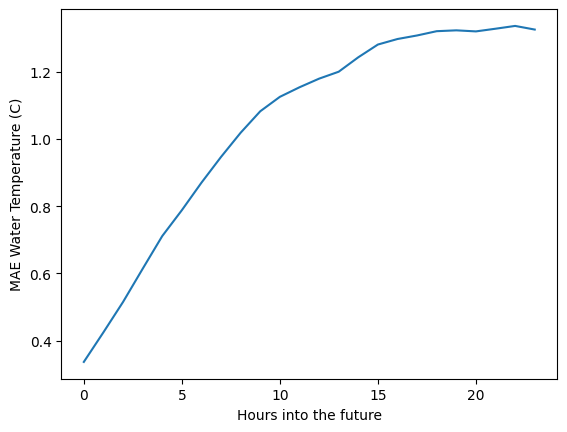

In [121]:
mae_horizon = []

for h in range(24):
    mae = np.mean(
        np.abs(
            temp_data['test_truth'][:, h]
            - temp_data['test_preds'][:, h]
        )
    )

    mae_horizon.append(mae)

plt.plot(mae_horizon)
plt.ylabel(f"MAE {target_column}")
plt.xlabel("Hours into the future")

Text(0.5, 0, 'MAE Water Temperature (C) for 24hr forecast')

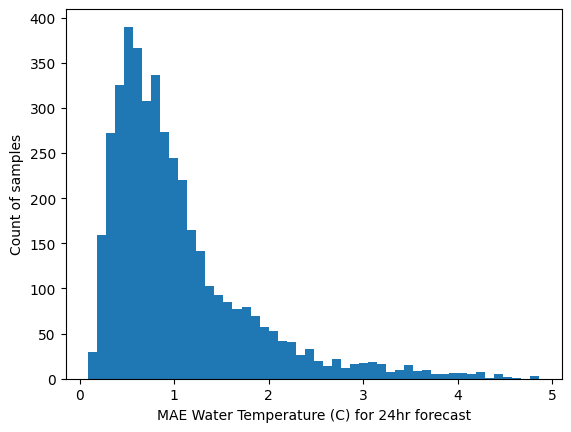

In [123]:
# make a bell curve/historgram of maes
plt.hist(maes, bins=50)
plt.ylabel("Count of samples")
plt.xlabel(f"MAE {target_column} for 24hr forecast")

## Plotting Functions

In [10]:
import datetime

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_week_window(res, day):
    """
    Visualize model forecast for a chosen day + the actual week leading up.
    
    Parameters
    ----------
    res : dict
        Output dictionary from train_model_for_target()
    day : str or datetime
        The day you want to visualize (the forecast day)
    """
    target = res["target_col"]
    df = res["X_scaler"].mean_  # dummy line to show res exists

    # Extract required model outputs
    test_idx = res["test_index"]                  # timestamps for each forecast
    preds = res["test_preds"]                     # shape (N, 24)
    truth = res["test_truth"]                     # shape (N, 24)

    df_full = res["full_df"] if "full_df" in res else None
    if df_full is None:
        raise ValueError("To use plot_week_window, store original df in res. Modify training function to add res['full_df']=df.")

    # Convert day input
    day = pd.to_datetime(day)
    # Find matching forecast sample (model predicts starting at 'day')
    try:
        idx = np.where(test_idx == day)[0][0]
    except:
        raise ValueError(f"Day {day.date()} is not a valid forecast day in the test set.")

    pred_day_values = preds[idx]
    true_day_values = truth[idx]

    # Build time axis for the 24-hour prediction
    pred_times = pd.date_range(day, periods=24, freq="h")

    # One week of historical actual data
    week_start = day - pd.Timedelta(days=7)
    week_data = df_full[target].loc[week_start:day]

    # --- Plotting ---
    plt.figure(figsize=(12,6))

    # Plot historical week
    plt.plot(week_data.index, week_data.values, label="Previous 7 days (actual)", color="blue")

    # Plot 24-hour prediction
    plt.plot(pred_times, pred_day_values, label="Forecast (next 24h)", color="red")

    # Plot true 24-hour values
    plt.plot(pred_times, true_day_values, label="True values (next 24h)", color="green", linestyle="--")
    r2 = r2_score(true_day_values,pred_day_values)
    print(f"R2: {r2:.4f}")
    plt.axvline(day, color="black", linestyle=":", label="Forecast start")
    plt.title(f"Week Before + 24-Hour Forecast for {day.date()}")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


R2: 0.6950


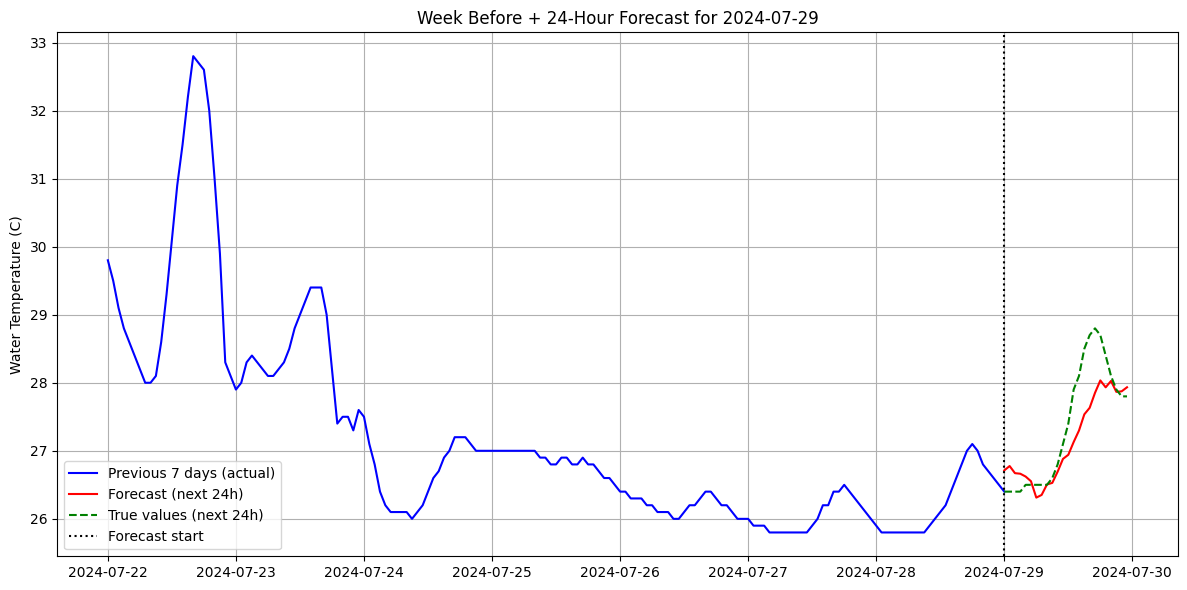

In [55]:
plot_week_window(temp_data, "2024-07-29")

In [27]:
def plot_test_daily(res, hr_out=0):
    """
    Plot full test set:
    - Each day's 24-hour prediction averaged to 1 value
    - Each day's true 24-hour target averaged to 1 value
    """
    target = res["target_col"]
    
    test_idx = res["test_index"]        # timestamps for each forecast
    preds = res["test_preds"]           # shape (N, 24)
    truth = res["test_truth"]           # shape (N, 24)
    print(len(test_idx))
    # Apply rolling average of roll hours
    # pred_daily = pd.DataFrame(preds.flatten()).rolling(window=roll).mean()
    # true_daily = pd.DataFrame(truth.flatten()).rolling(window=roll).mean()
    pred_daily = pd.DataFrame(preds[:,hr_out],index=test_idx).rolling(24).mean()
    true_daily = pd.DataFrame(truth[:,hr_out],index=test_idx).shift(hr_out).rolling(24).mean()
    # print(true_daily.sum())
    # return pd.DataFrame(preds[:,0])
    # --- Plot ---
    plt.figure(figsize=(12,6))
    plt.plot(true_daily, label="True (Rolling)", color="green",linewidth=2)
    plt.plot(pred_daily, label="Predicted (Rolling)", color="red", alpha=0.7,linewidth=2)
    # r2 = r2_score(true_daily.dropna(),pred_daily.dropna())
    # print(f"Rolling R2: {r2:.4f}")
    plt.title(f"Prediction of {target} at {hr_out+1} hours before")
    plt.ylabel(target)
    plt.xlabel("Date")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


4225


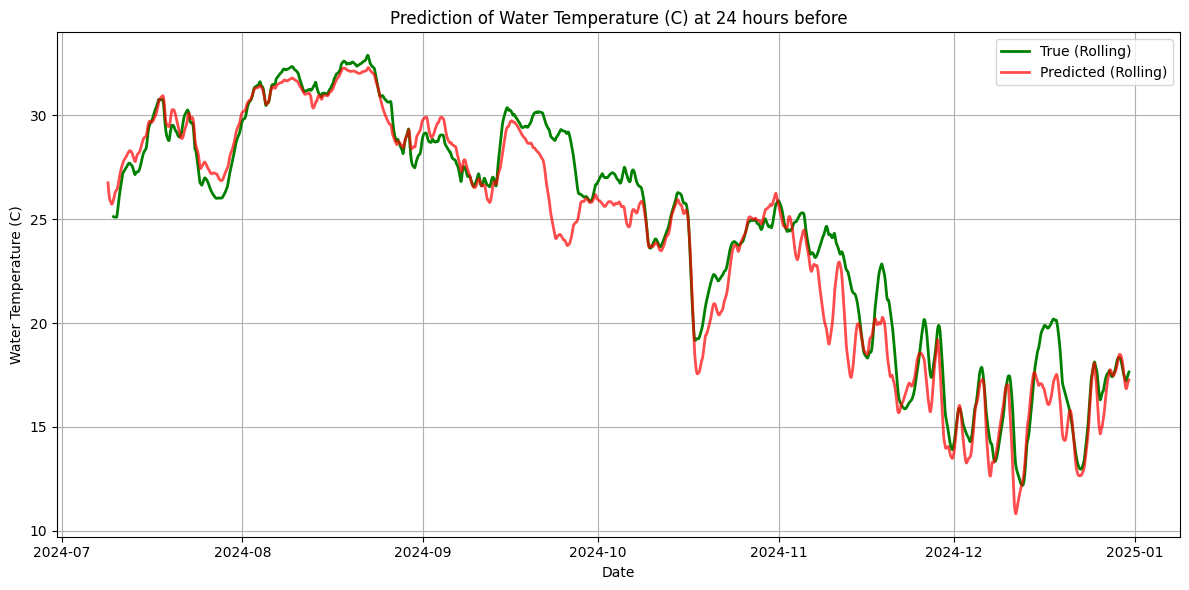

4225


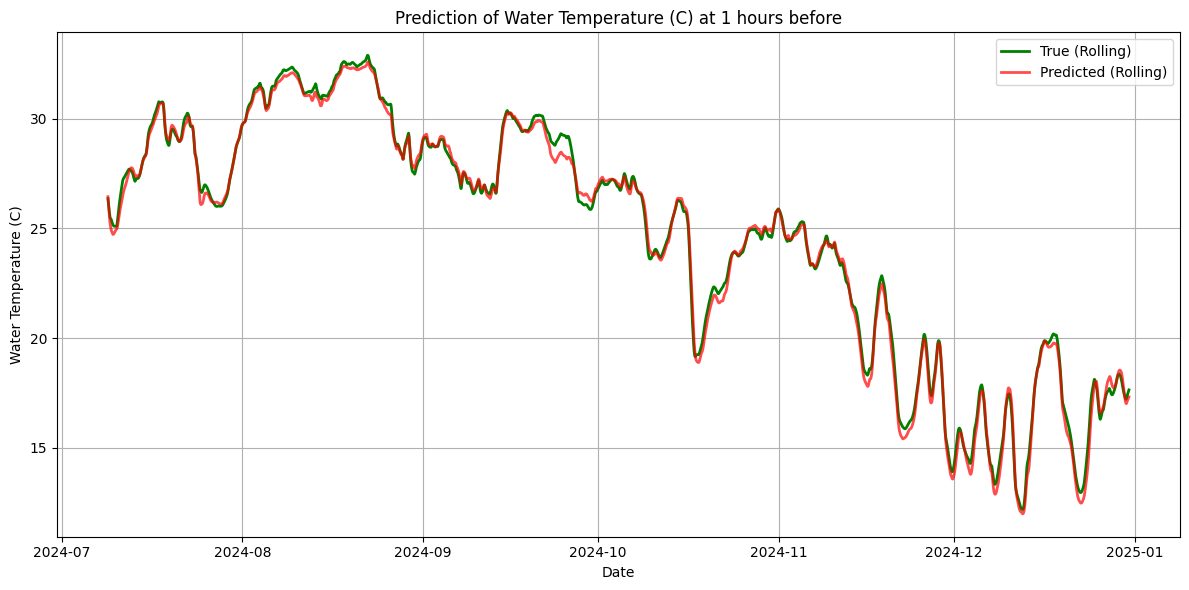

In [37]:
plot_test_daily(temp_data,hr_out=23)
plot_test_daily(temp_data,hr_out=0)

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import pandas as pd

def plot_all_predictions(res):
    """
    Plot:
    - True daily rolling (24-hour)
    - 24 rolling curves for each forecast horizon (0–23 hours ahead)
    - Colorbar indicating forecast horizon
    """

    target = res["target_col"]
    
    test_idx = res["test_index"]        # index of prediction times
    preds = res["test_preds"]           # shape (N, 24)
    truth = res["test_truth"]           # shape (N, 24)

    # True rolling using the first hour of each truth window
    true_daily = pd.Series(truth[:,0], index=test_idx).rolling(24).mean()

    # Color mapping for horizon
    cmap = cm.viridis
    norm = colors.Normalize(vmin=1, vmax=24)

    # -----------------------------
    # Create figure + axis explicitly
    # -----------------------------
    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot true rolling

    # Plot each horizon with rolling
    for h in range(24):
        series = pd.Series(preds[:, h], index=test_idx).rolling(24).mean()
        ax.plot(series, color=cmap(norm(h)), alpha=0.7)

    # Create ScalarMappable for colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    # -----------------------------
    # FIX: Explicitly attach colorbar to `ax`
    # -----------------------------
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Forecast Horizon (hours ahead)", fontsize=12)
    ax.plot(true_daily, color="black", linewidth=2.0, label="True (24h rolling)")

    # Layout
    ax.set_title(f"24-hour Rolling Forecast Performance: {target}", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel(target)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    plt.show()


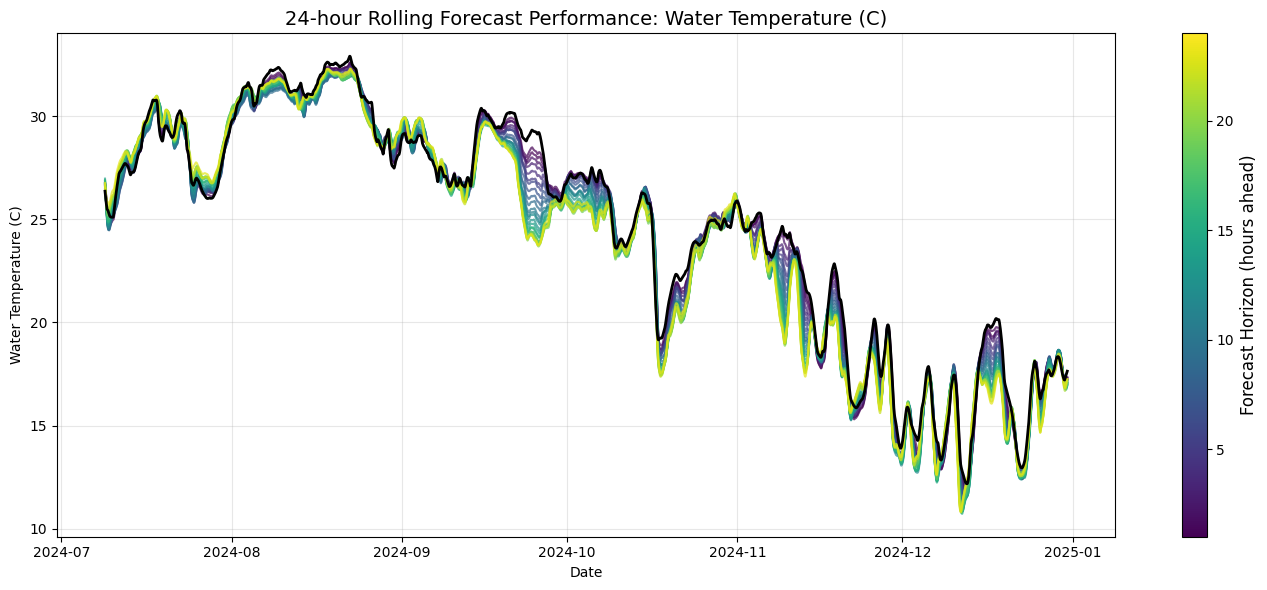

In [38]:
plot_all_predictions(temp_data)

In [89]:
from sklearn.metrics import r2_score
import pandas as pd

def compute_horizon_r2(res):
    """
    Compute R² for each forecast horizon (0–23 hours ahead).
    
    Parameters
    ----------
    res : dict containing:
        - res["test_preds"]: shape (N, 24)
        - res["test_truth"]: shape (N, 24)

    Returns
    -------
    pd.Series indexed 0..23 of R² values.
    """
    
    preds = res["test_preds"]      # (N, 24)
    truth = res["test_truth"]      # (N, 24)

    r2_values = {}

    for h in range(24):
        y_true = truth[:, h] # Predict the h-th hour ahead. So when h = 0 we predict the very next hour and compare to the dataset shifted by 1. Whn h is 23 we predict 24 hours ahead and compare to the 24th entry in truth
        y_pred = preds[:, h]

        # Remove NaN if any exist due to rolling or preprocessing
        mask = (~pd.isna(y_true)) & (~pd.isna(y_pred))
        if mask.sum() > 1:
            r2_values[h] = r2_score(y_true[mask], y_pred[mask])
        else:
            r2_values[h] = float("nan")
    print(y_true,y_pred)
    return pd.Series(r2_values, name="R2_by_horizon")
compute_horizon_r2(temp_data)

[25.3      25.3      25.2      ... 17.199999 16.9      16.6     ] [28.343935 28.151447 28.067797 ... 17.526691 17.183216 16.94242 ]


0     0.994314
1     0.990537
2     0.985547
3     0.979100
4     0.971128
5     0.964457
6     0.957210
7     0.949836
8     0.941894
9     0.935910
10    0.930710
11    0.926720
12    0.923715
13    0.921294
14    0.916405
15    0.912472
16    0.910226
17    0.908995
18    0.907260
19    0.907013
20    0.906141
21    0.906321
22    0.904700
23    0.905417
Name: R2_by_horizon, dtype: float64

In [30]:
def compare_r2_horizons(res_dict):
    """
    Given a dictionary of {name: res}, compute and plot horizon R² for each.

    Parameters
    ----------
    res_dict : dict
        Keys are model names / parameter settings
        Values are the corresponding `res` dictionaries (with test_preds/test_truth)

    Returns
    -------
    pd.DataFrame where rows=horizons and columns=each model's R²
    """
    
    # Compute R2 for each model
    results = {}
    for name, res in res_dict.items():
        results[name] = compute_horizon_r2(res)

    r2_df = pd.DataFrame(results)   # shape (24, num_models)

    # ---- Plot ----
    plt.figure(figsize=(12, 6))
    
    for name in r2_df.columns:
        plt.plot(r2_df.index+1, r2_df[name], label=name, linewidth=2)

    plt.xlabel("Forecast Horizon (hours ahead)")
    plt.ylabel("R²")
    plt.xticks(range(1,25))
    plt.title("R² Across Forecast Horizons for Multiple Models")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()
    
    return r2_df


# Develop a model for each parameter

In [17]:
import pickle

In [18]:
try:
    
    super_data = pickle.load(open("super_data.pkl",'rb'))
    print("Reading Models")
except:
    print("Training Models")
    super_data = {}
    for param in df.columns:
        print(f"Training model for parameter: {param}")
        model_res = train_model_for_target(df,
                                        target_col=param,
                                        input_len=168, # one week
                                        out_len=24, # one day
                                        batch_size=64,
                                        n_epochs=50,
                                        lr=1e-3,
                                        hidden_size=64,
                                        num_layers=2,
                                        device=None,
                                        verbose=True,
                                        patience=6)
        super_data[param] = model_res
    pickle.dump(open("super_data.pkl",'wb'))

Reading Models


c:\Users\epzausch\.conda\envs\pnxg\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\epzausch\.conda\envs\pnxg\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [19]:
import matplotlib_inline.backend_inline

Results for parameter: Discharge (cfs)
{'mae': 172.97637939453125, 'rmse': 574.1168823242188, 'mse': 365978.40625, 'r2': 0.6769313812255859, 'n_samples': 4225}
R2: -4.7991


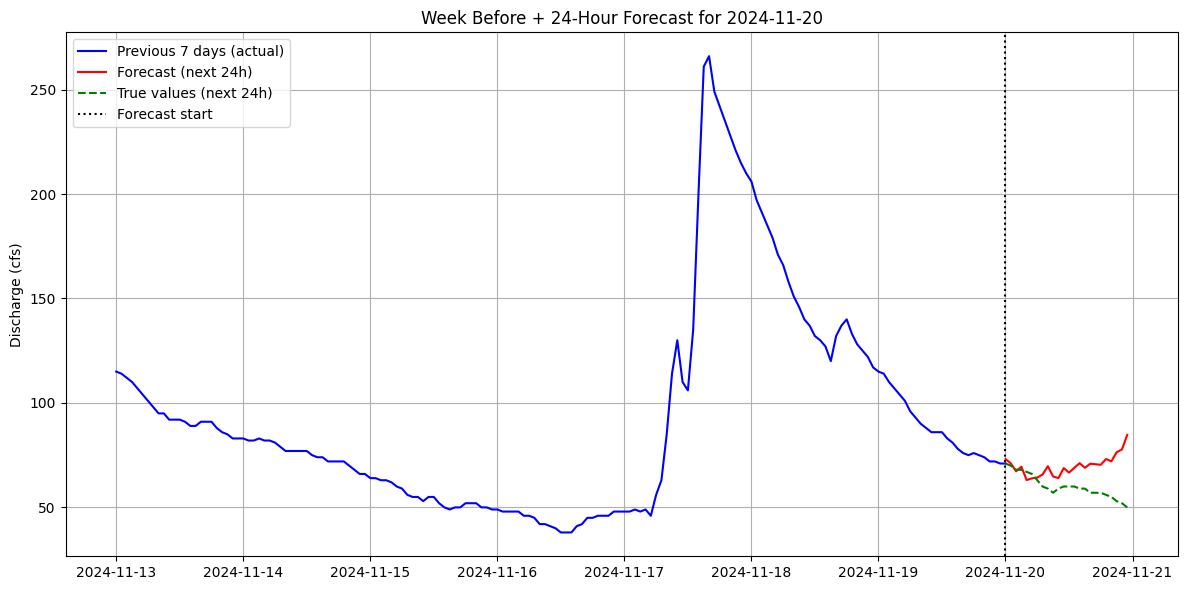

4225


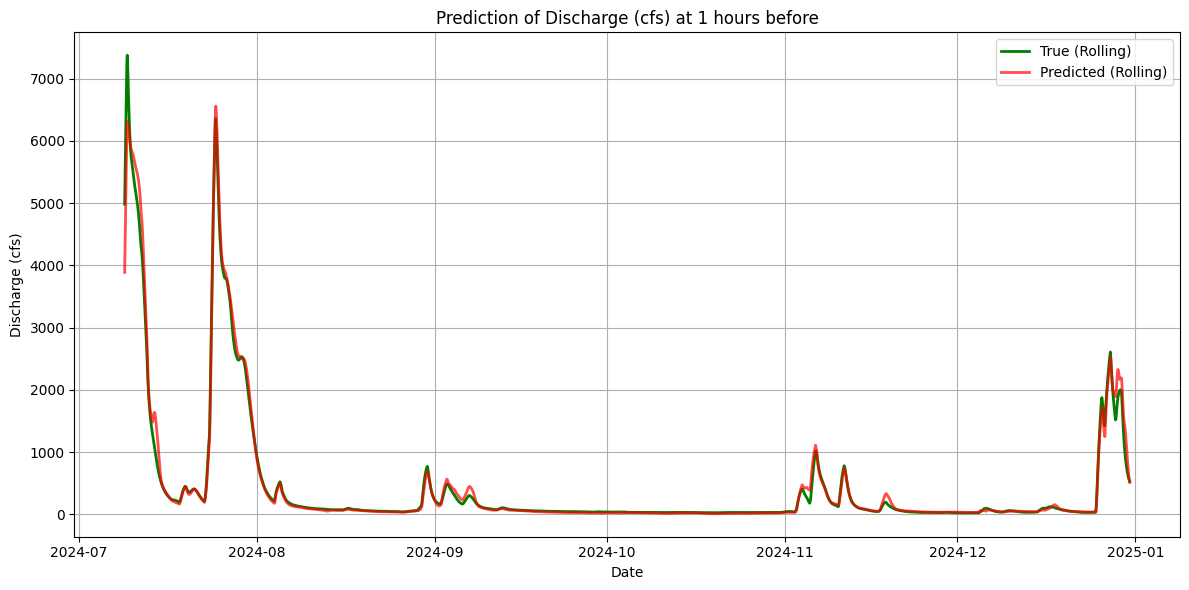

Results for parameter: Water Temperature (C)
{'mae': 1.0502758026123047, 'rmse': 1.3695850372314453, 'mse': 1.9677724838256836, 'r2': 0.9414597153663635, 'n_samples': 4225}
R2: 0.6096


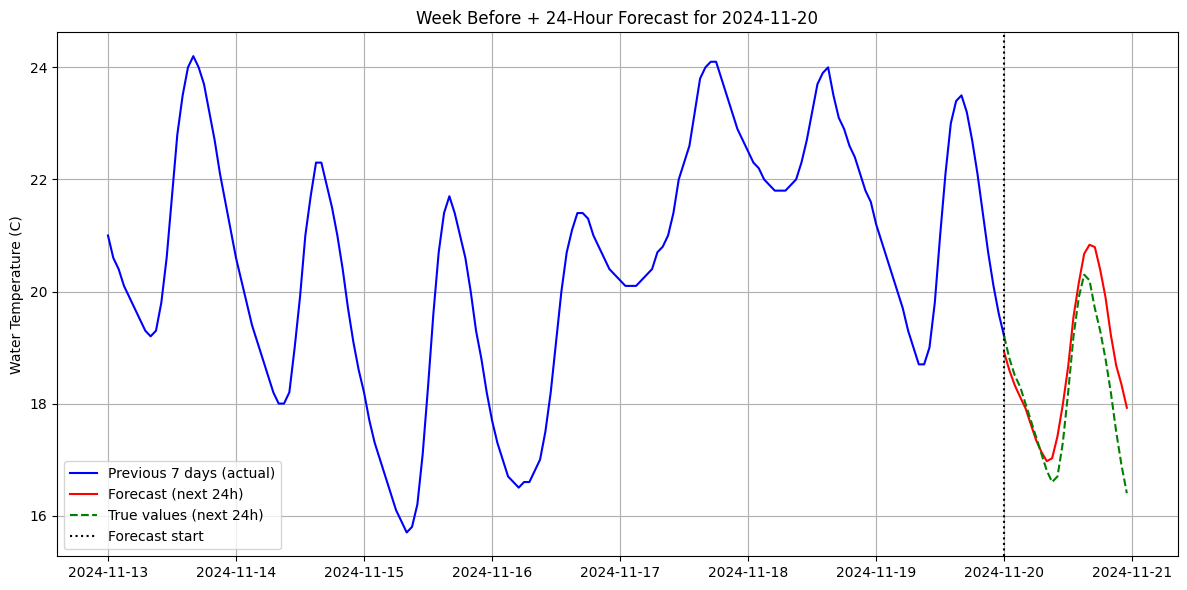

4225


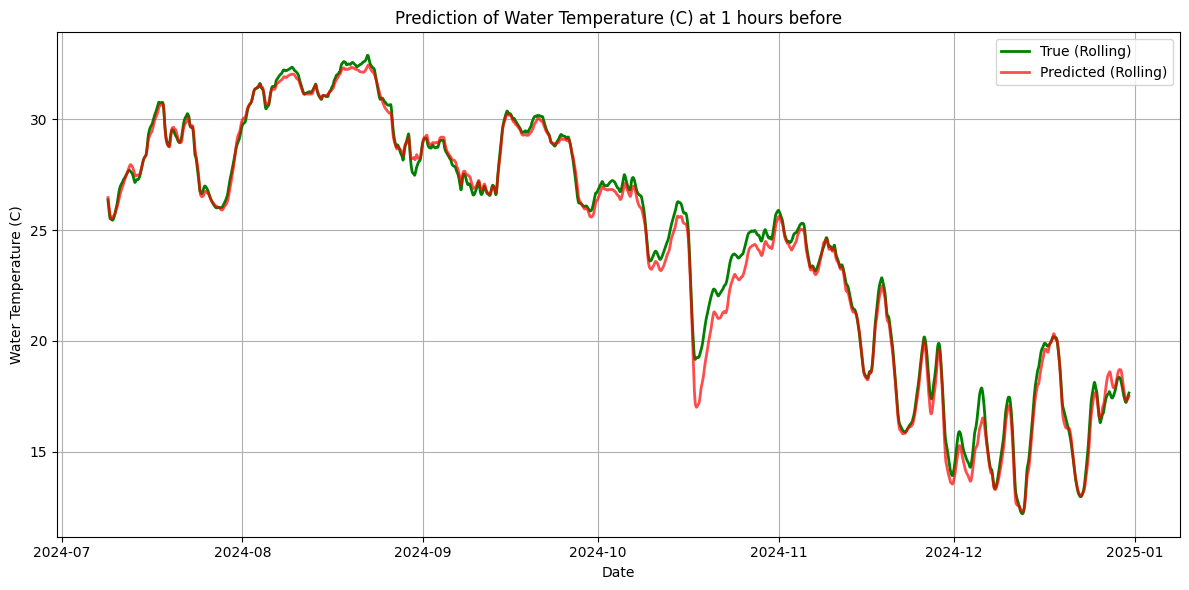

Results for parameter: pH (std units)
{'mae': 0.08834689855575562, 'rmse': 0.13374385237693787, 'mse': 0.018215319141745567, 'r2': 0.9100950360298157, 'n_samples': 4225}
R2: 0.4847


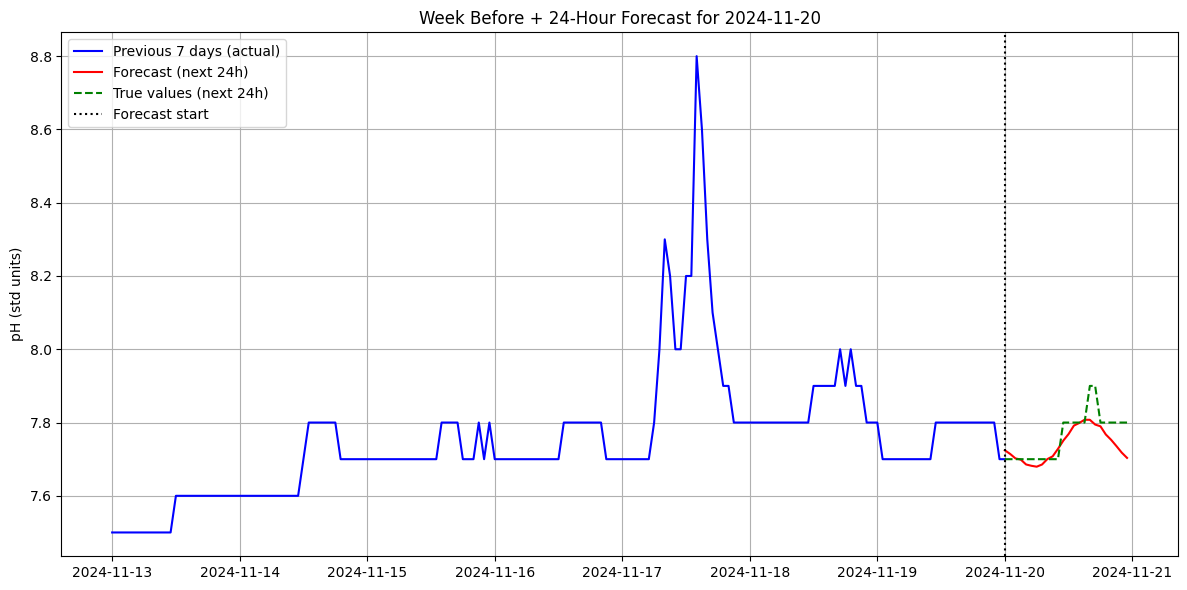

4225


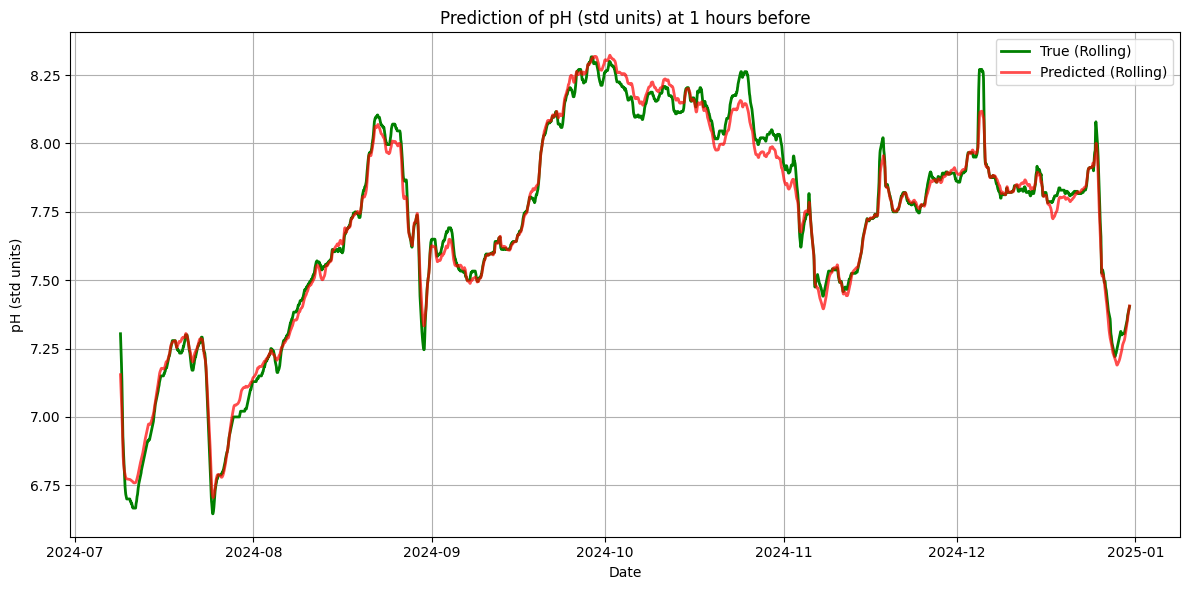

Results for parameter: Dissolved Oxygen (mg/L)
{'mae': 0.30483129620552063, 'rmse': 0.42824169993400574, 'mse': 0.1890638917684555, 'r2': 0.9348990321159363, 'n_samples': 4225}
R2: -0.5974


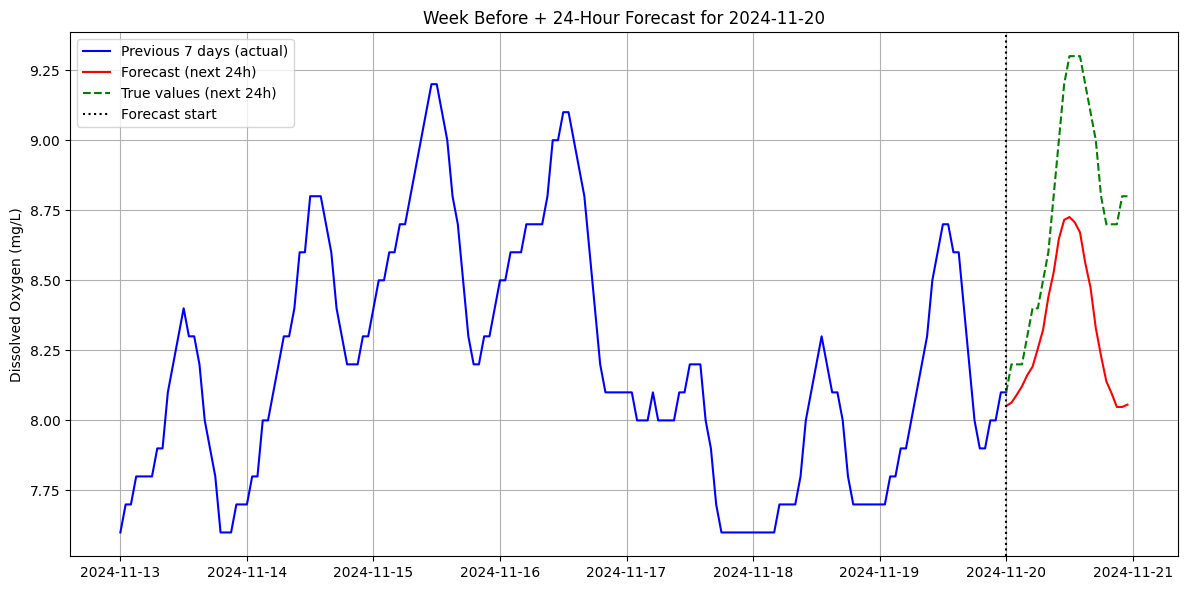

4225


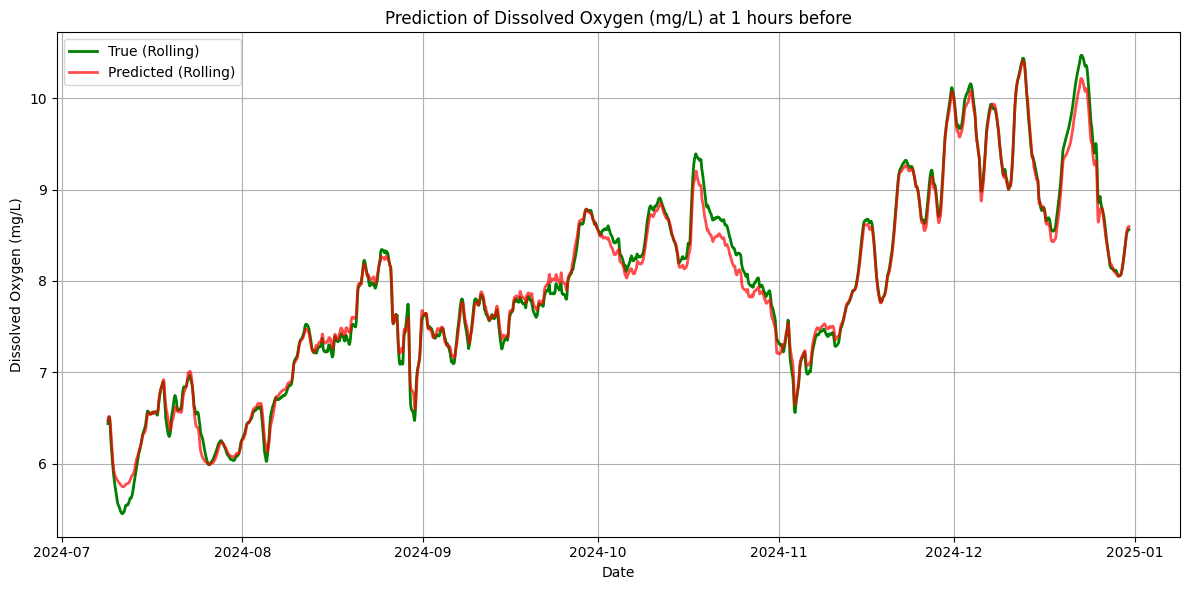

Results for parameter: Specific Conductance (uS/cm)
{'mae': 30.18935203552246, 'rmse': 48.35862350463867, 'mse': 2529.39990234375, 'r2': 0.9305149912834167, 'n_samples': 4225}
R2: -5.4678


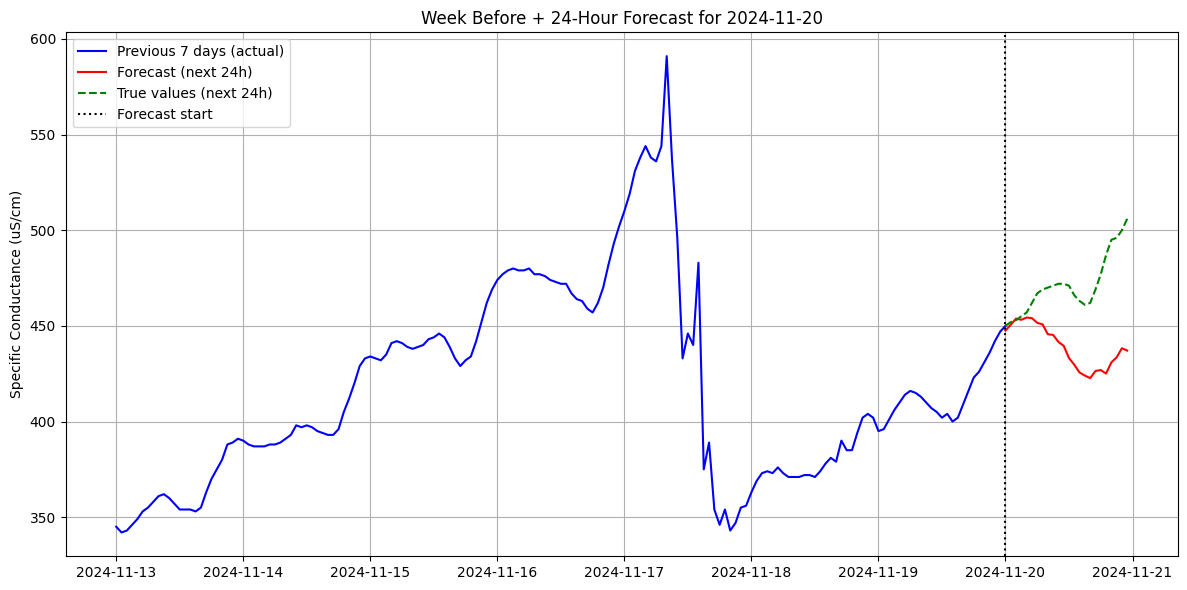

4225


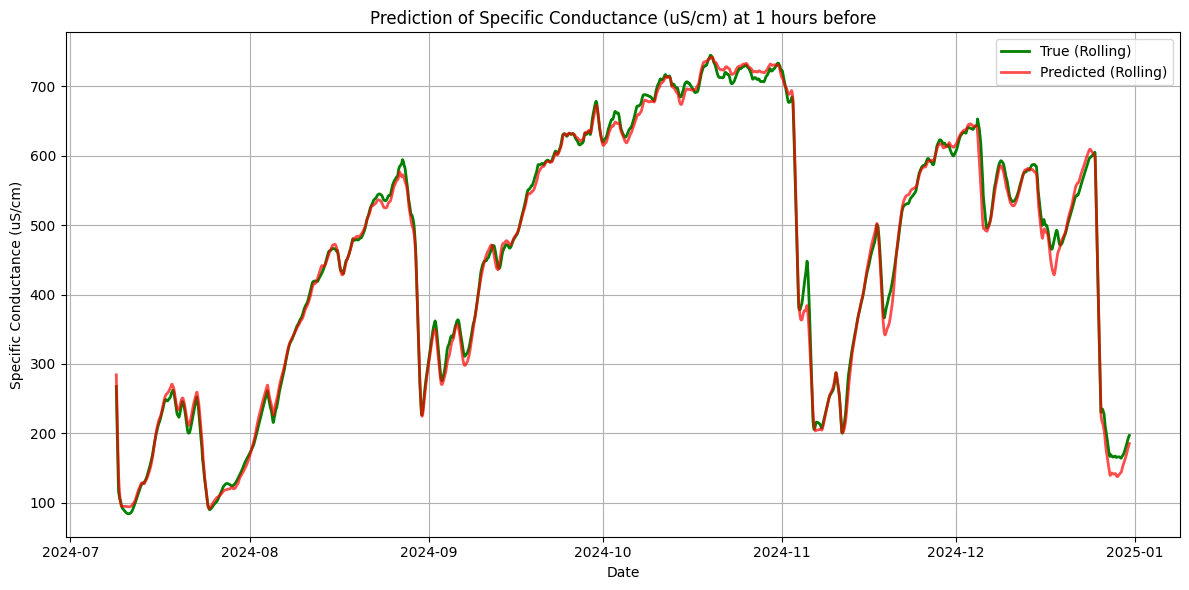

Results for parameter: Turbidity (NTU)
{'mae': 13.337477684020996, 'rmse': 26.738088607788086, 'mse': 745.0402221679688, 'r2': 0.6269981265068054, 'n_samples': 4225}
R2: 0.3368


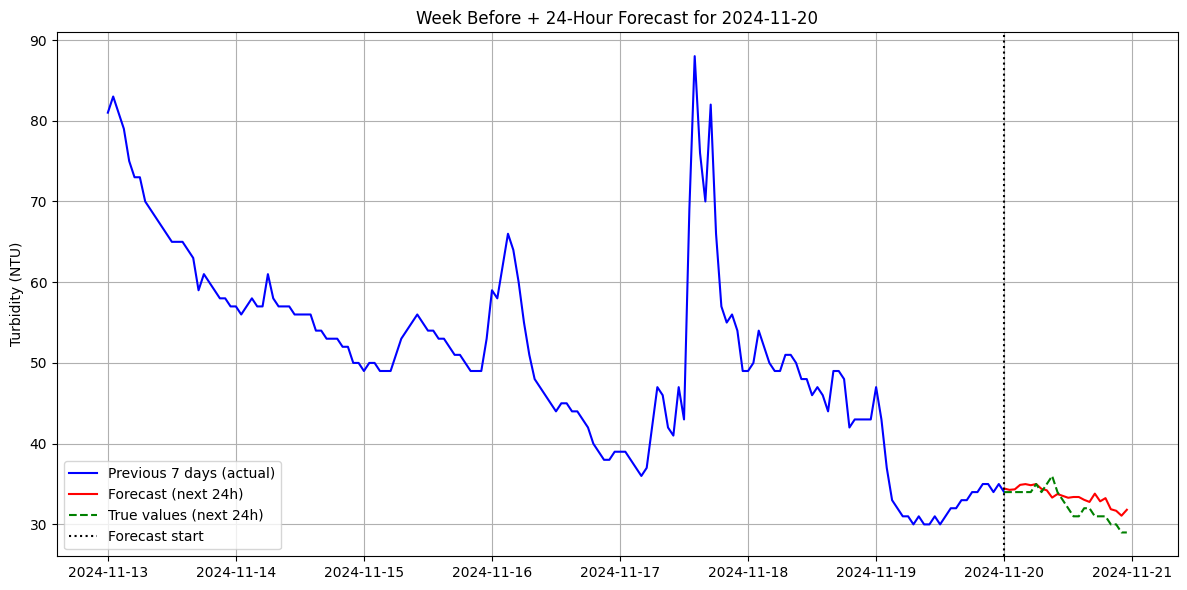

4225


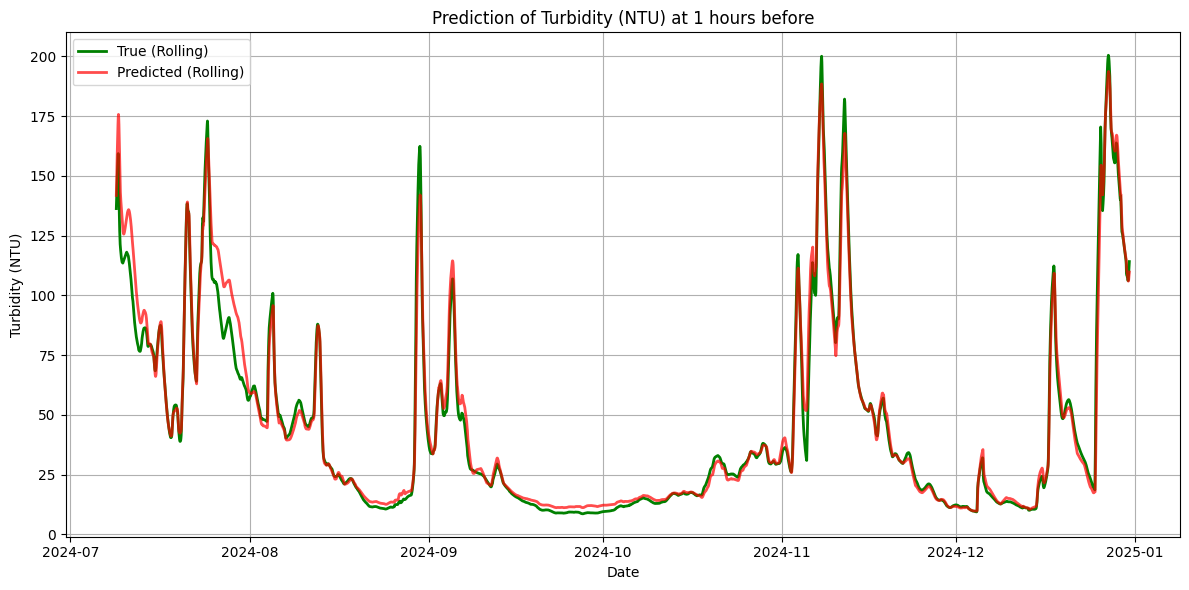

Results for parameter: Total Organic Carbon (mg/L)
{'mae': 0.5799623131752014, 'rmse': 0.9574505686759949, 'mse': 0.9622300267219543, 'r2': 0.7970864772796631, 'n_samples': 4225}
R2: 0.0000


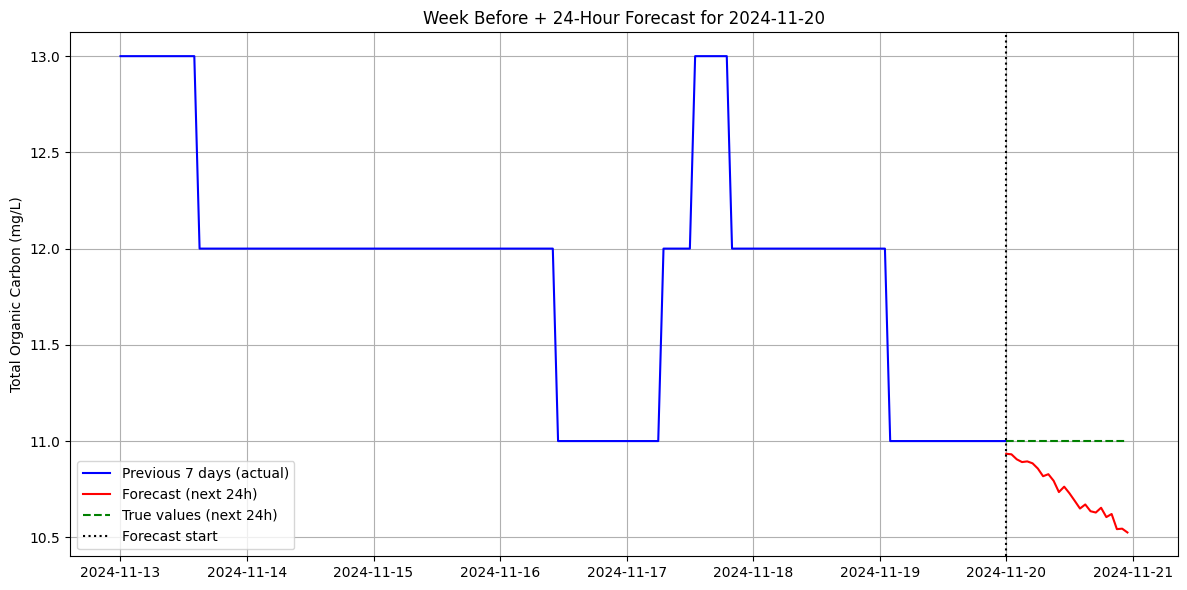

4225


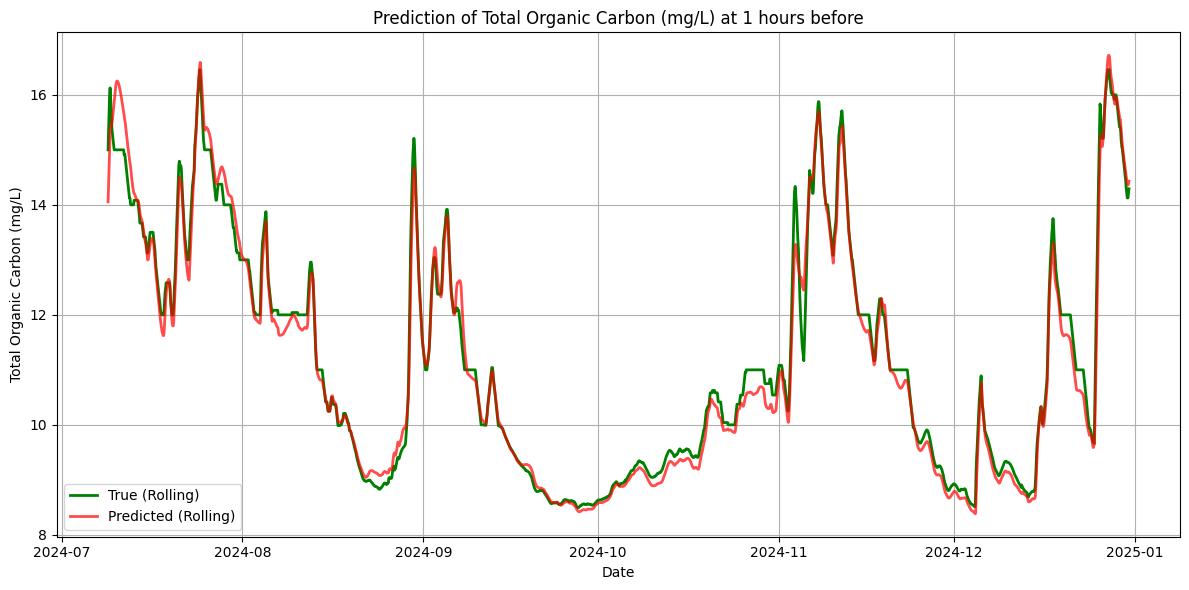

Results for parameter: Nitrate + Nitrite (mg/L)
{'mae': 0.364485502243042, 'rmse': 0.5957154035568237, 'mse': 0.3797546625137329, 'r2': 0.9297457337379456, 'n_samples': 4225}
R2: -6.3768


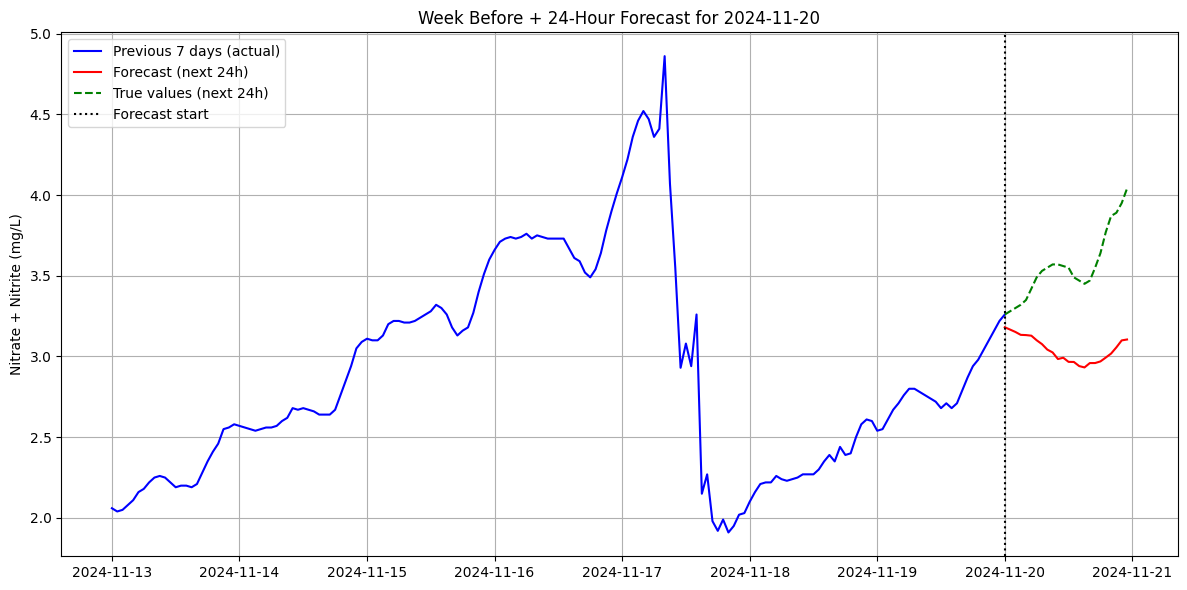

4225


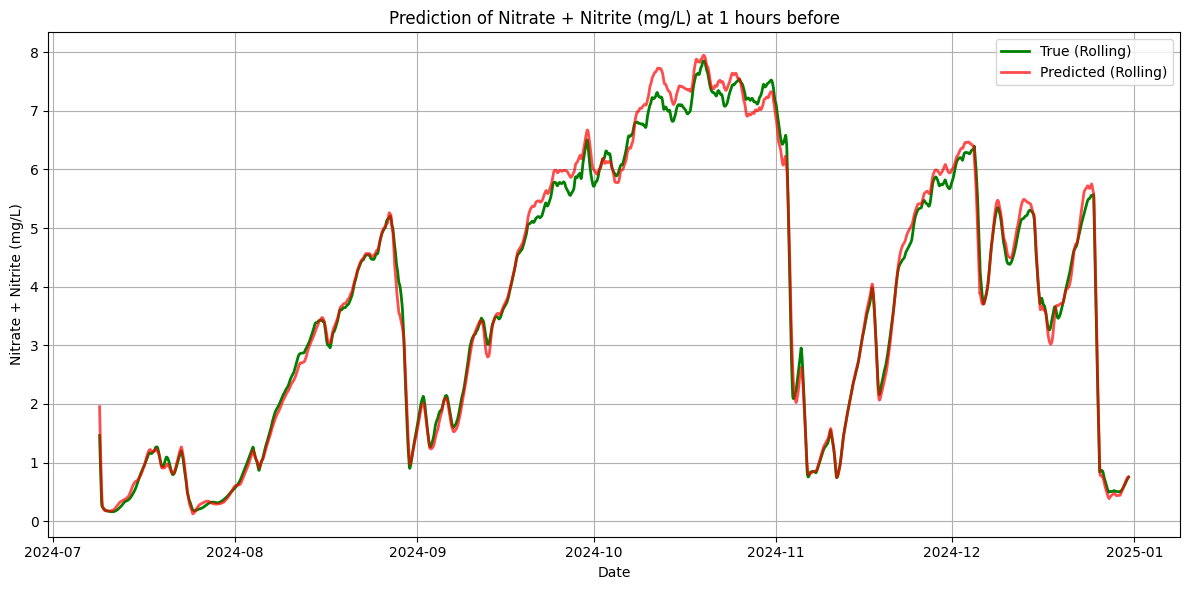

Results for parameter: Total Phosphorus (mg/L)
{'mae': 0.07219613343477249, 'rmse': 0.11288335174322128, 'mse': 0.013356700539588928, 'r2': 0.9348633289337158, 'n_samples': 4225}
R2: -8.2869


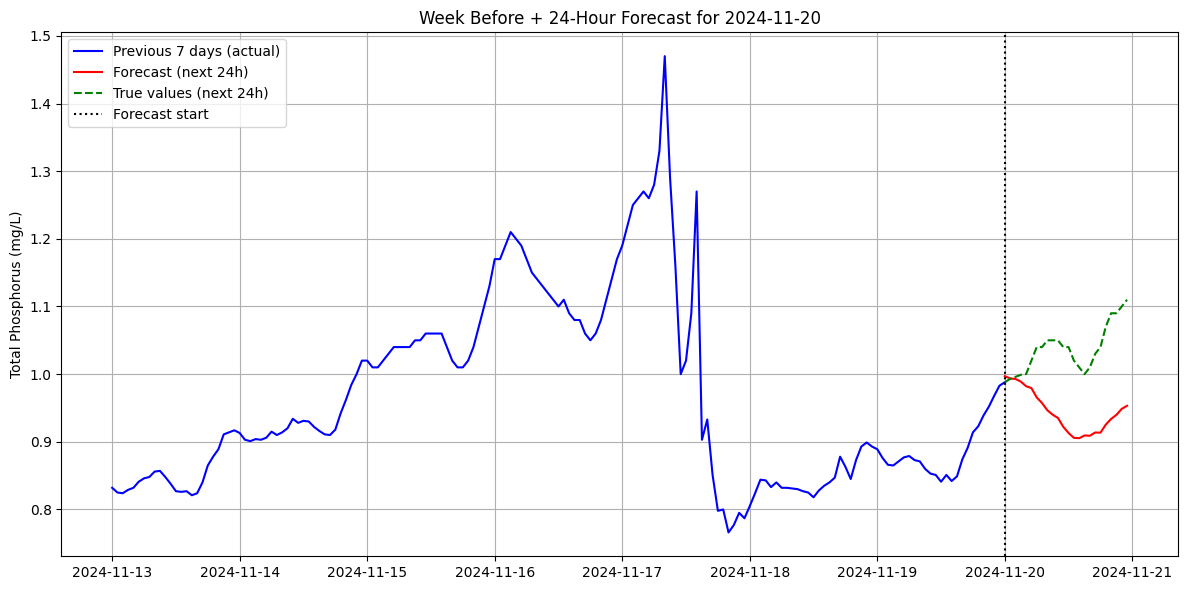

4225


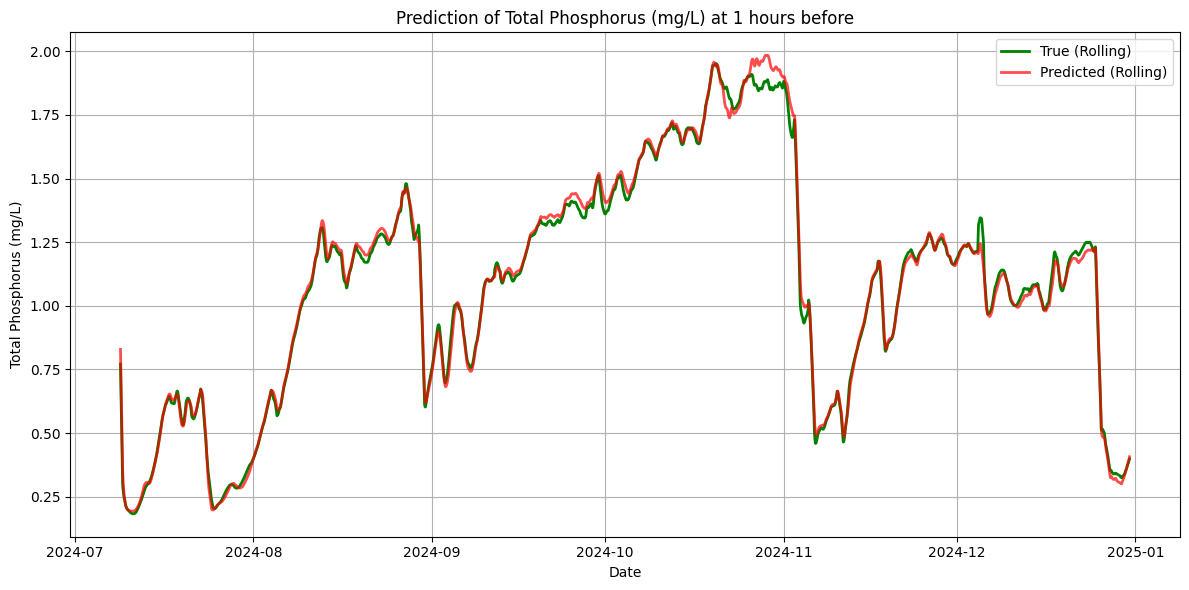

Results for parameter: Precipitation 1hr (in)
{'mae': 0.07156585901975632, 'rmse': 0.3737456798553467, 'mse': 0.14041264355182648, 'r2': -0.01097389031201601, 'n_samples': 4225}
R2: 0.0000


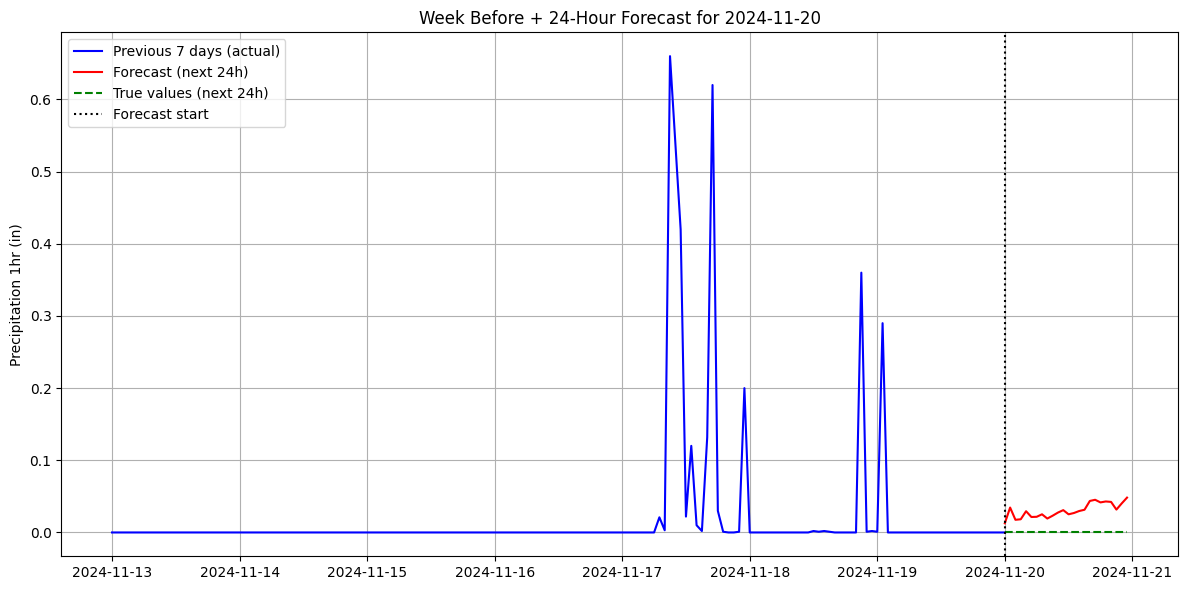

4225


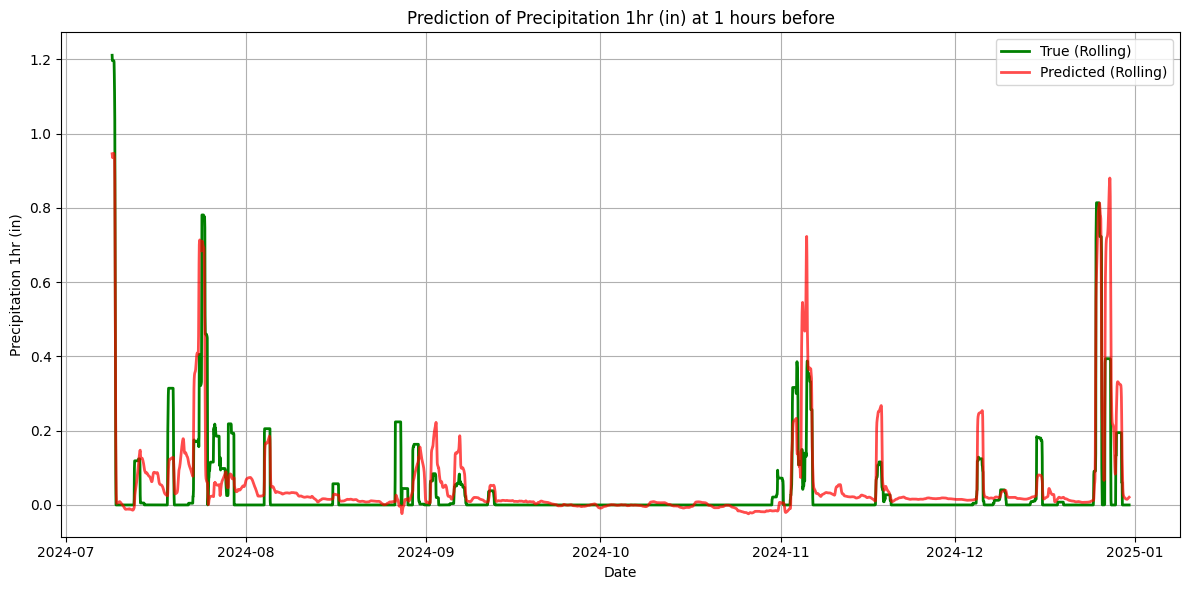

In [21]:
for param, res in super_data.items():
    print(f"Results for parameter: {param}")
    print(res['metrics'])
    res['full_df'] = df
    plot_week_window(res, "2024-11-20")
    plot_test_daily(res)

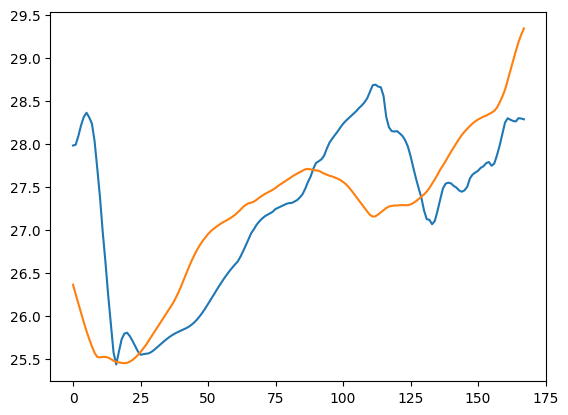

In [22]:
plt.plot(super_data['Water Temperature (C)']['test_preds'].mean(axis=1)[0:168])
plt.plot(super_data['Water Temperature (C)']['test_truth'].mean(axis=1)[0:168])

## Compare each parameter

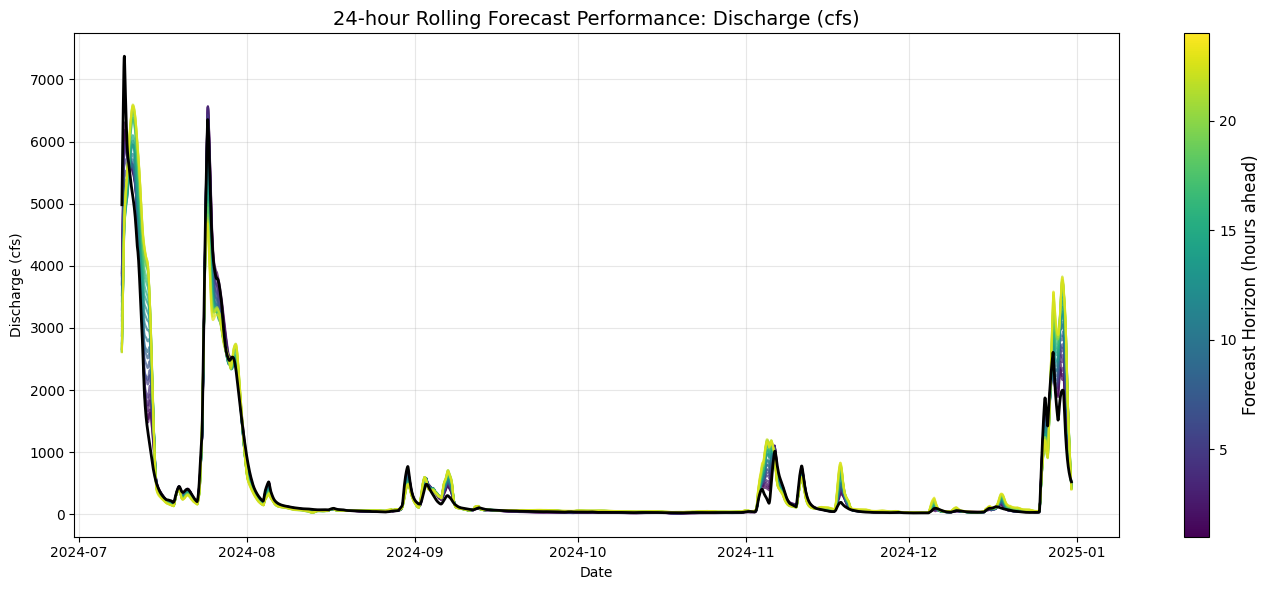

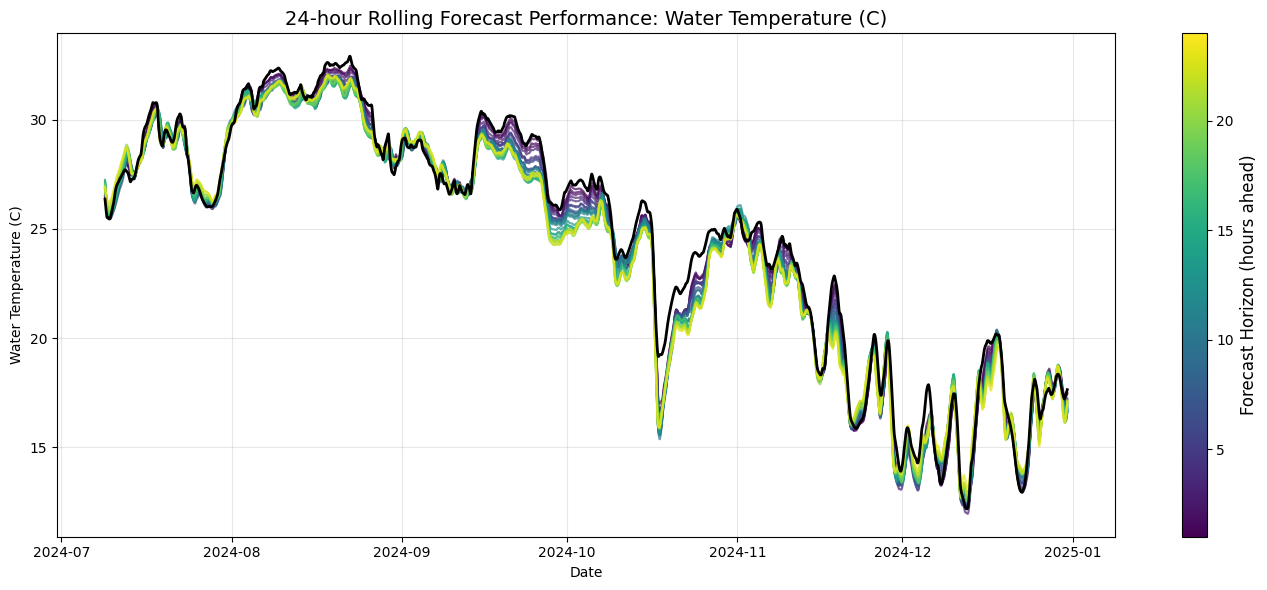

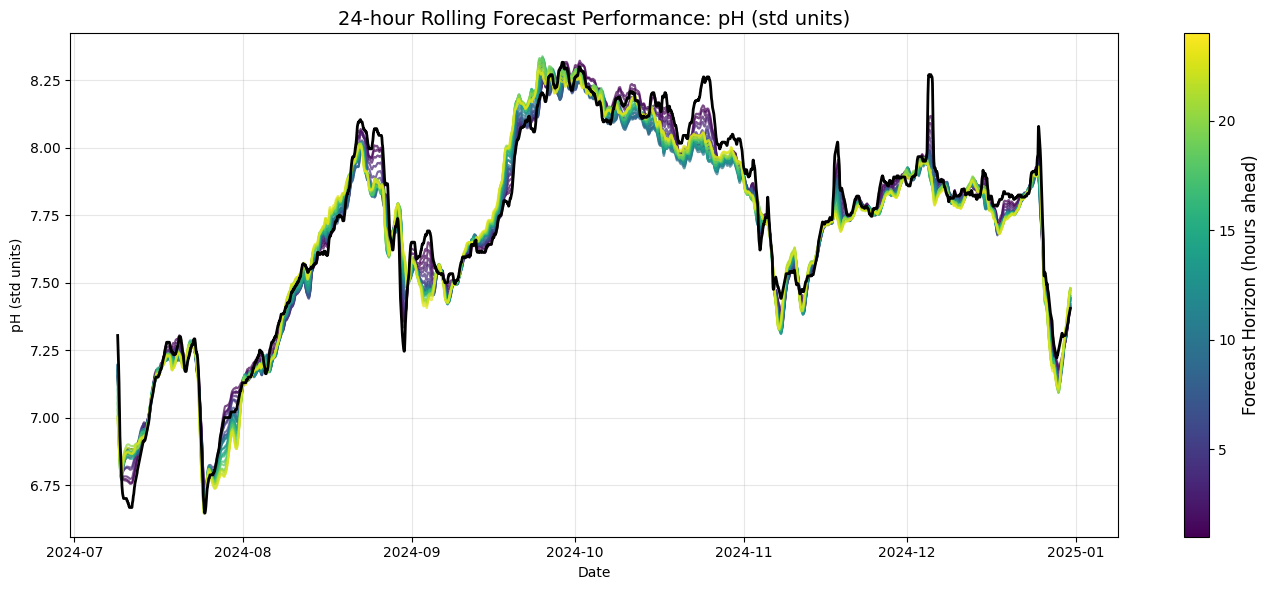

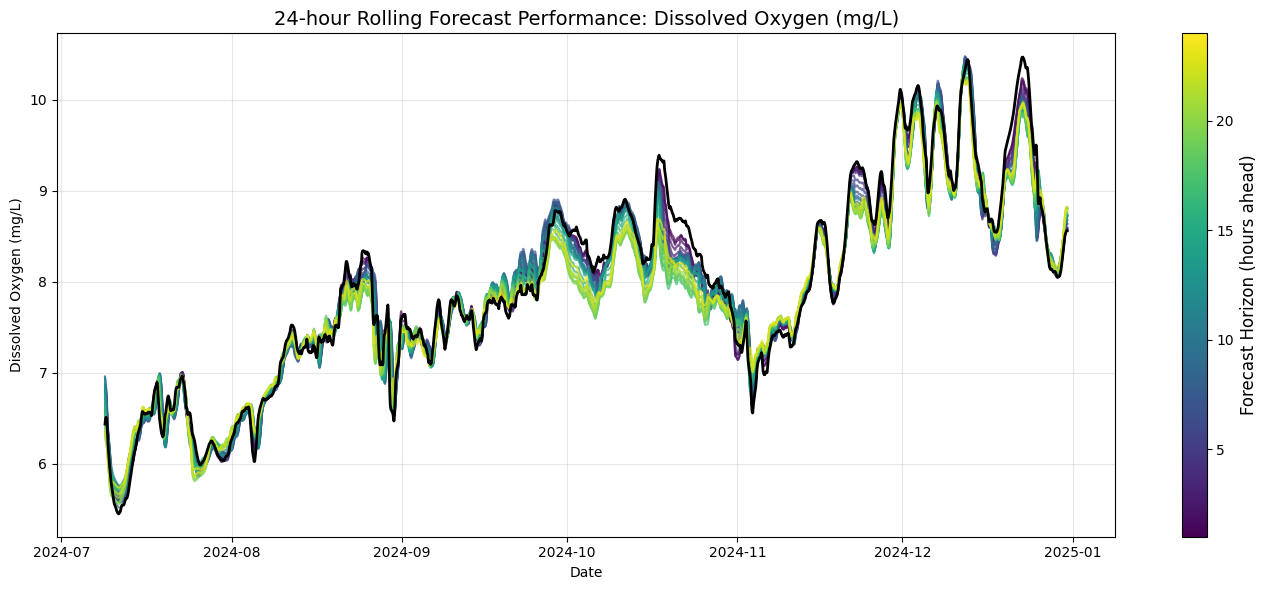

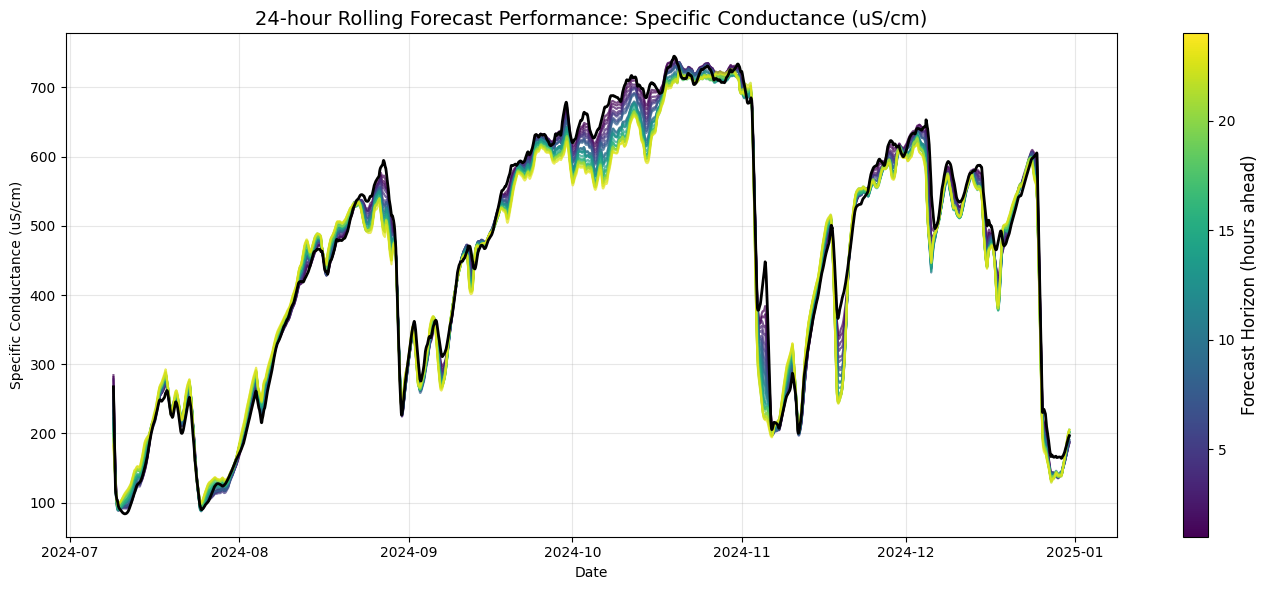

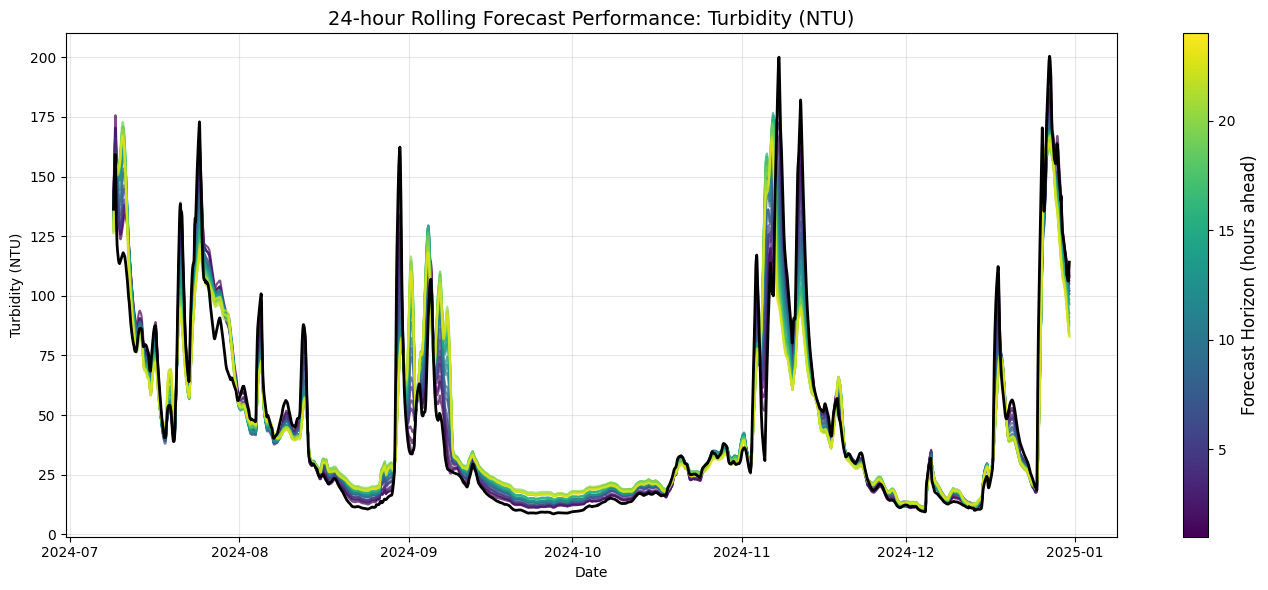

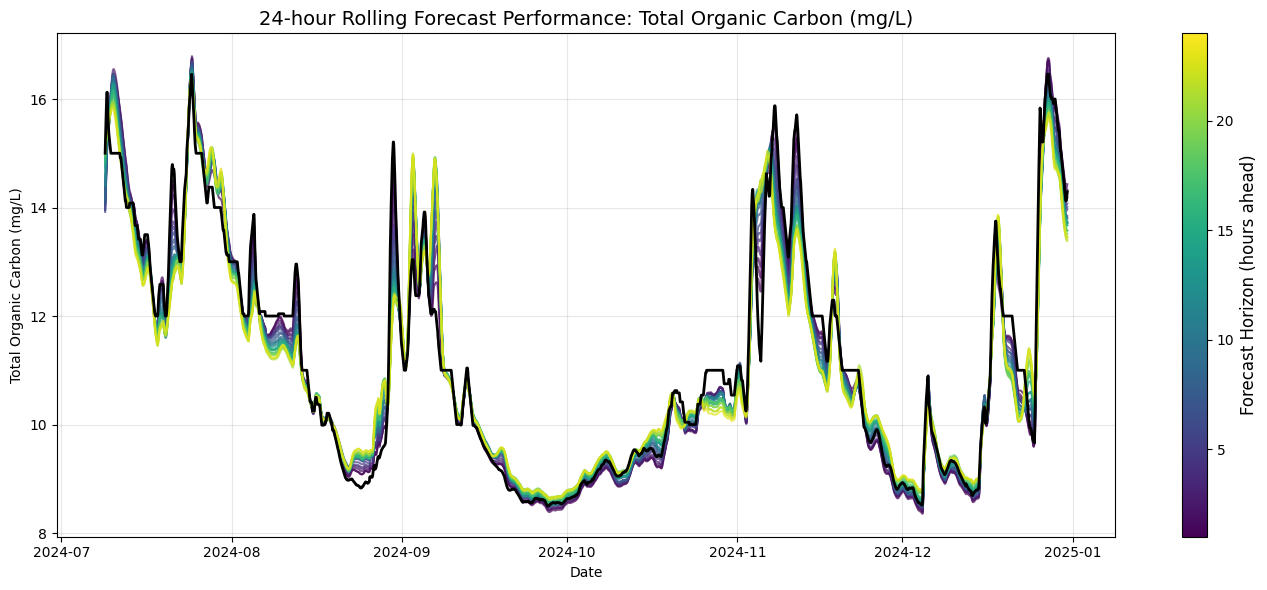

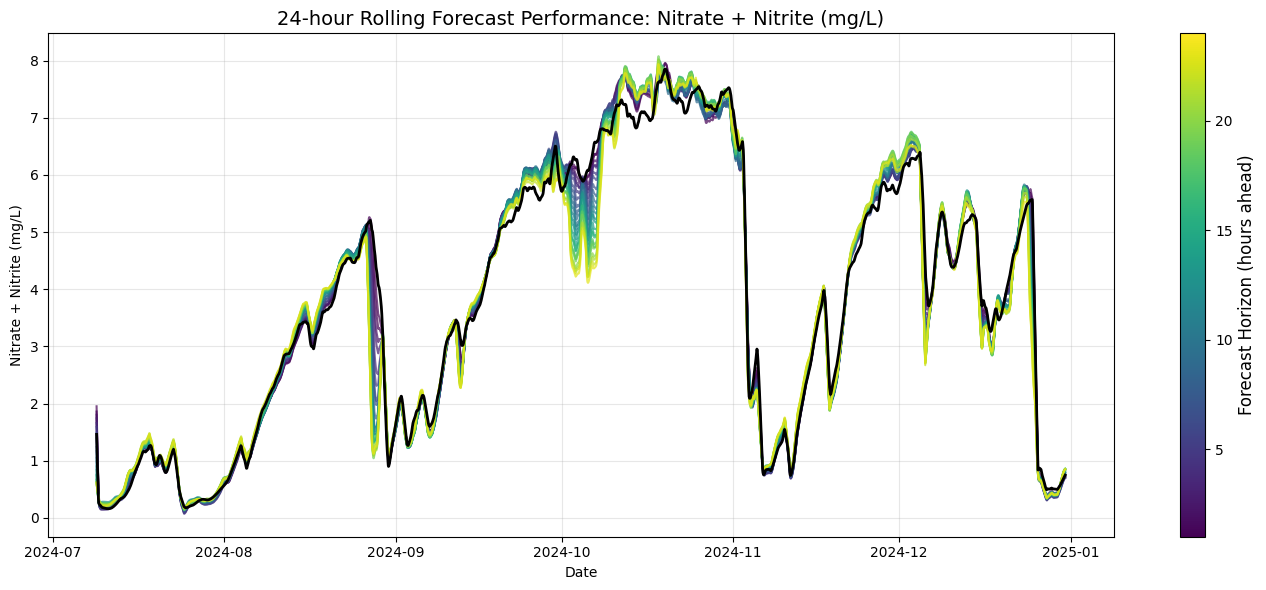

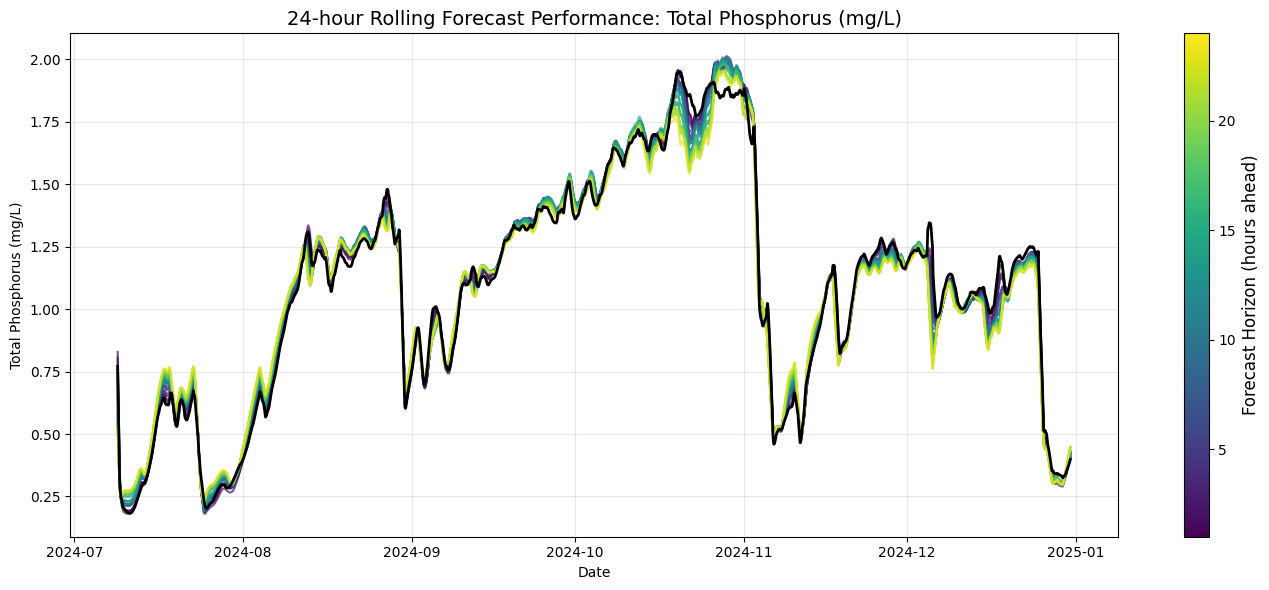

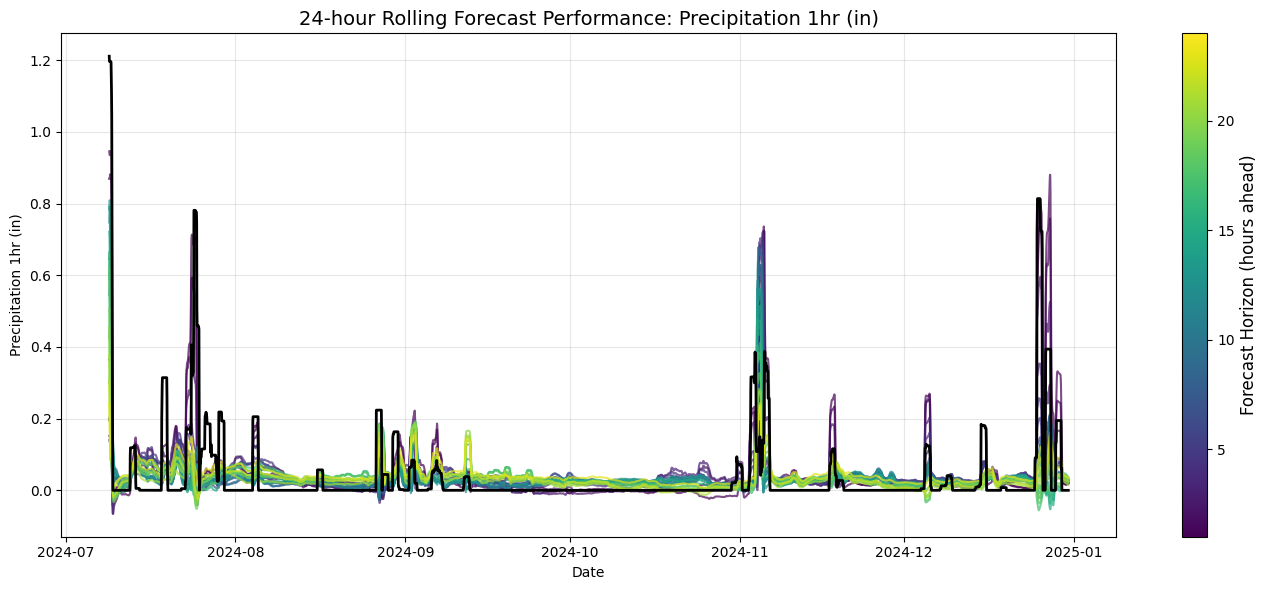

In [23]:
for param_data in super_data.values():
    plot_all_predictions(param_data) 

# Compare Params

C:\Users\epzausch\AppData\Local\Temp\ipykernel_35776\2180593228.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(r2s.keys(),rotation=90)


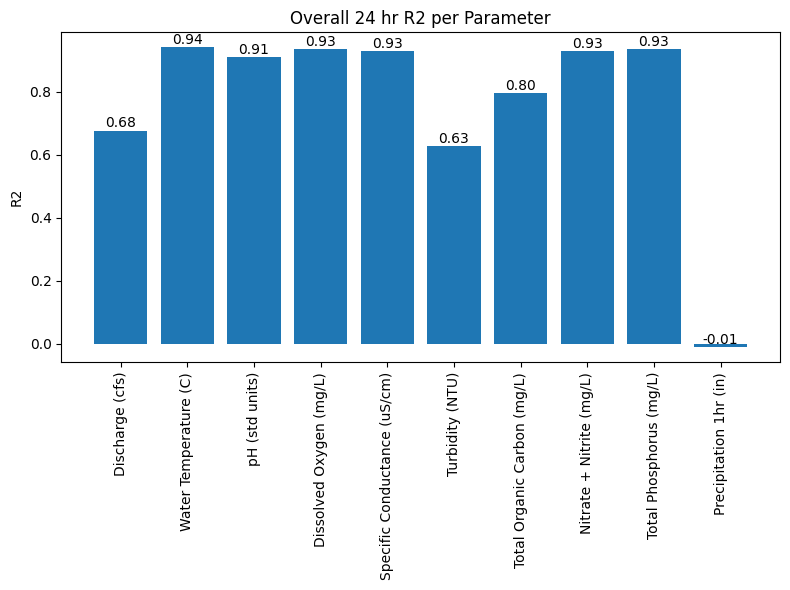

In [24]:
# This shows the average across the 24 hr window
fig,ax = plt.subplots(figsize=(8,6))


r2s = {}
for param, res in super_data.items():
    # print(f"Results for parameter: {param}")
    # print(res['metrics'])
    
    r2s[param] = res['metrics']['r2']

ax.bar(r2s.keys(), r2s.values())
ax.set_title("Overall 24 hr R2 per Parameter")
ax.set_xticklabels(r2s.keys(),rotation=90)

for i in range(len(r2s)):
    ax.text(i, r2s[list(r2s.keys())[i]] + 0.01, f"{r2s[list(r2s.keys())[i]]:.2f}", ha='center')

ax.set_ylabel("R2")
plt.tight_layout()
plt.show()

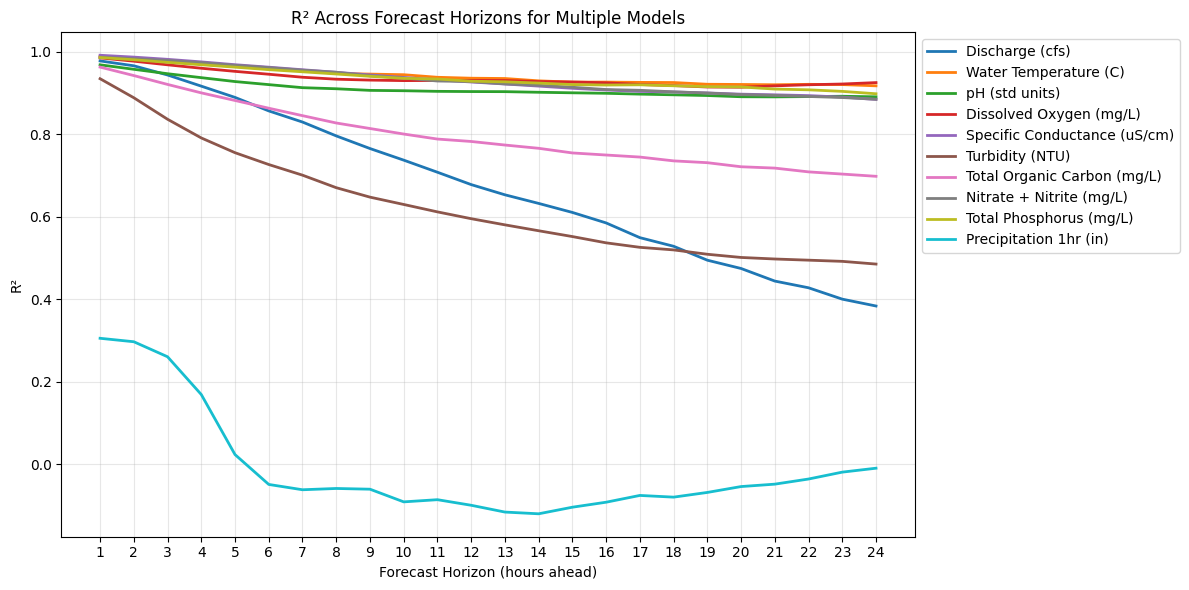

In [25]:
r2_horizon = compare_r2_horizons(super_data)

<Axes: >

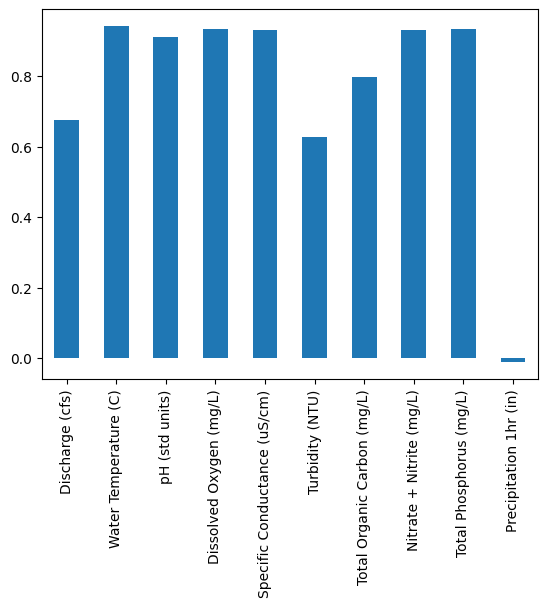

In [26]:
r2_horizon.mean().plot(kind='bar') # 

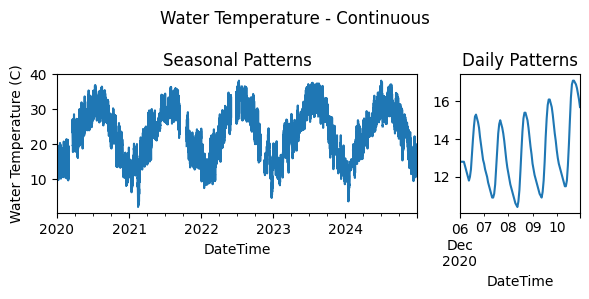

In [79]:
def plot_season_vs_day(param,title,day=168*48+96):
    fig,ax = plt.subplots(1,2,figsize=(6,3),width_ratios=[3,1])
    df[param].plot(ax=ax[0])
    ax[0].set_ylabel(param)
    ax[0].set_title("Seasonal Patterns")
    df[param].iloc[day:day+24*5].plot(ax=ax[1])
    ax[1].set_title("Daily Patterns")
    plt.suptitle(title)
    plt.tight_layout()
plot_season_vs_day('Water Temperature (C)',"Water Temperature - Continuous")

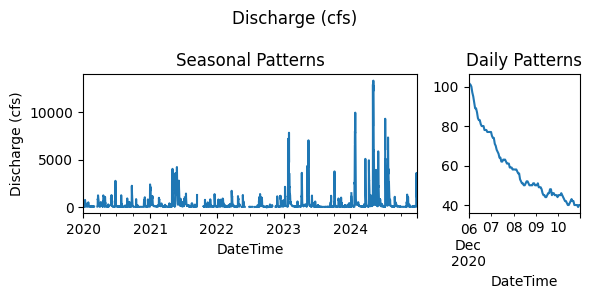

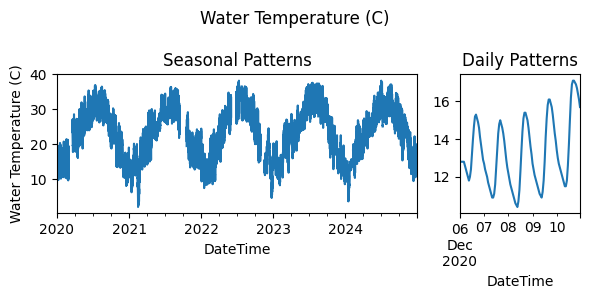

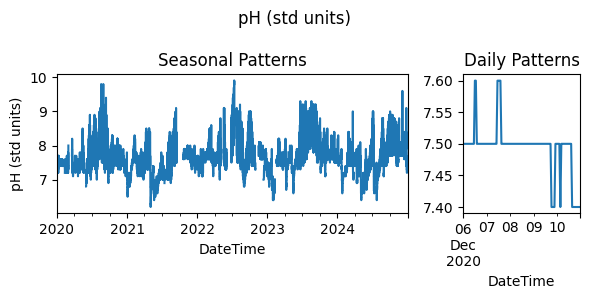

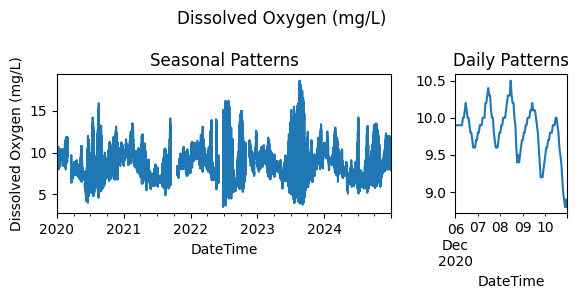

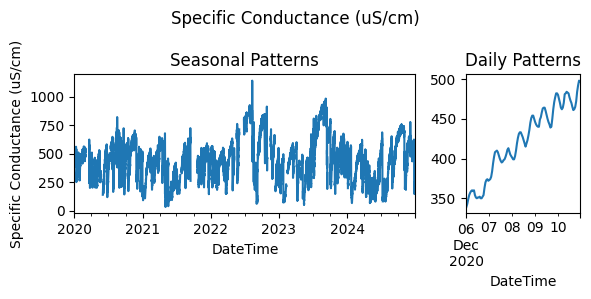

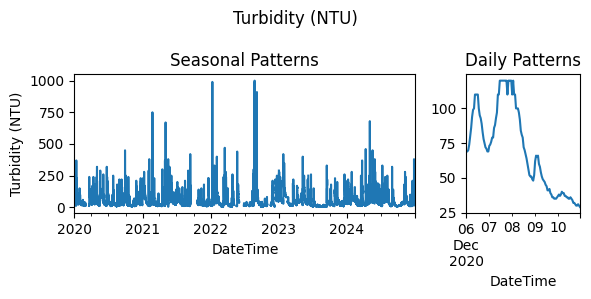

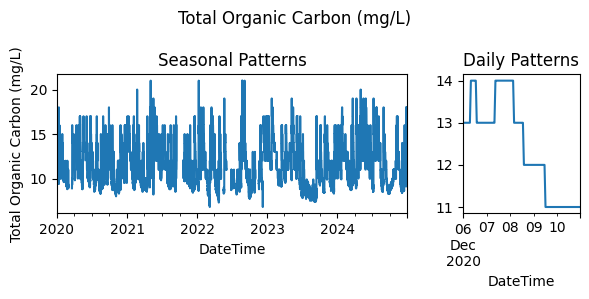

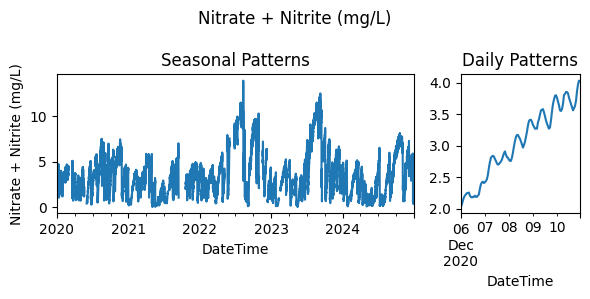

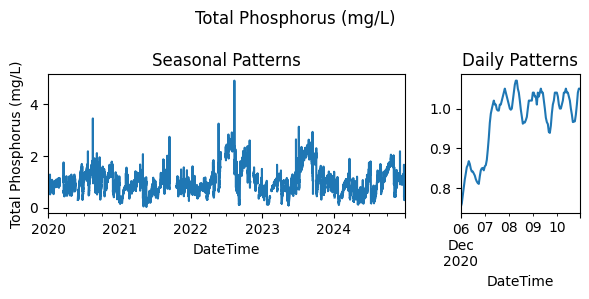

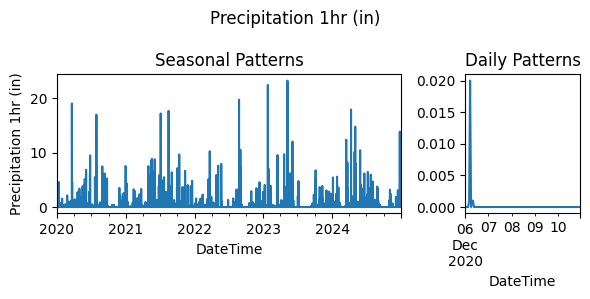

In [85]:
for param in df.columns:
    plot_season_vs_day(param,title=param)

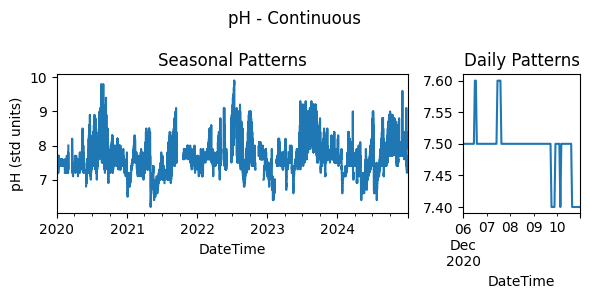

In [84]:
plot_season_vs_day('pH (std units)',title='pH - Continuous')